# 🍄 🍄‍🟫 Machine Learning Assignment – Mushroom Edibility Classification 🍄‍🟫 🍄

**🍄‍🟫 Dataset:** [Mushroom Edibility Classification (Kaggle)](https://www.kaggle.com/datasets/devzohaib/mushroom-edibility-classification)  
**🍄‍🟫 Dataset file:** 'secondary_data.csv' 

**🍄‍🟫 Author:** Kyoko Schelfhout

**🍄‍🟫 Course:** BIT07 - Machine Learning

---
## 🍄‍🟫 Part 1: Loading in the needed modules

In [1]:
# Import all modules
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer, KNNImputer

# Model selection
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from scipy.stats import uniform

# Regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

# Clustering
from sklearn.cluster import KMeans

# Metrics
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

---
## 🍄‍🟫 Part 2: Reading in the data

In [2]:
data = pd.read_csv('secondary_data.csv', sep=';')
# data.head()


---
## 🍄‍🟫 Part 3: Describing the Dataset
#### The first five rows of the dataset

In [3]:
data.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


#### The column names

In [4]:
print("The column names inside the dataset:")
print("____________________________________")
print(data.columns.tolist())
# data.columns

The column names inside the dataset:
____________________________________
['class', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-height', 'stem-width', 'stem-root', 'stem-surface', 'stem-color', 'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season']


#### Number of rows and columns

In [5]:
# Number of rows and columns
print(f"Shape of the data: {data.shape}")
print("___________________")
print(f"  - Rows   : {data.shape[0]}")
print(f"  - Columns: {data.shape[1]}")

Shape of the data: (61069, 21)
___________________
  - Rows   : 61069
  - Columns: 21


#### Overview of data types and missing values

In [6]:
# Overview of data types 
print("Data dtypes:")
print("____________")
print(data.dtypes)

Data dtypes:
____________
class                    object
cap-diameter            float64
cap-shape                object
cap-surface              object
cap-color                object
does-bruise-or-bleed     object
gill-attachment          object
gill-spacing             object
gill-color               object
stem-height             float64
stem-width              float64
stem-root                object
stem-surface             object
stem-color               object
veil-type                object
veil-color               object
has-ring                 object
ring-type                object
spore-print-color        object
habitat                  object
season                   object
dtype: object


In [7]:
print("\nMissing values per column:")
print("_____________________________")
print(data.isnull().sum())


Missing values per column:
_____________________________
class                       0
cap-diameter                0
cap-shape                   0
cap-surface             14120
cap-color                   0
does-bruise-or-bleed        0
gill-attachment          9884
gill-spacing            25063
gill-color                  0
stem-height                 0
stem-width                  0
stem-root               51538
stem-surface            38124
stem-color                  0
veil-type               57892
veil-color              53656
has-ring                    0
ring-type                2471
spore-print-color       54715
habitat                     0
season                      0
dtype: int64


In [8]:
# The amount of rows with missing data
print(f"Nr of rows with missing data: {data.isna().any(axis=1).sum()}")

print("\n")
# Check for missing values (more visually)
print("Amount of missing data per column:")
print("__________________________________")
print(data.isnull().sum())

print("\n")
# The columns that have missing data
print("Columns having missing data:")
print("____________________________")
print(data.columns[data.isna().sum().values > 0])

Nr of rows with missing data: 61069


Amount of missing data per column:
__________________________________
class                       0
cap-diameter                0
cap-shape                   0
cap-surface             14120
cap-color                   0
does-bruise-or-bleed        0
gill-attachment          9884
gill-spacing            25063
gill-color                  0
stem-height                 0
stem-width                  0
stem-root               51538
stem-surface            38124
stem-color                  0
veil-type               57892
veil-color              53656
has-ring                    0
ring-type                2471
spore-print-color       54715
habitat                     0
season                      0
dtype: int64


Columns having missing data:
____________________________
Index(['cap-surface', 'gill-attachment', 'gill-spacing', 'stem-root',
       'stem-surface', 'veil-type', 'veil-color', 'ring-type',
       'spore-print-color'],
      dtype='object')


>From the number of rows with missing data and the amount of missing data per row it can be conluded that there is one row that is completly missing data: 'veil-type'.
This is also confirmed by the listing of the columns that have missing data.
===> This column 'veil-type' should be dropped

---
## 🍄‍🟫 Part 4: Exploring and Pre-processing

> ### Unique values
> First a look is taken at the columns with only 1 unique value and these columns will be removed.  

In [9]:
# Check for uninformative columns (contains only one unique value) 
cols_to_drop = []

# Making a loop to make it easier and faster to check all columns
for col in data.columns:
    if data[col].nunique() == 1:
        print(f"Column '{col}' has only one unique value: {data[col].unique()} — will be dropped")
        cols_to_drop.append(col)

data = data.drop(columns=cols_to_drop)

# to check if the column is unique or not for a specific column --> data["stem-root"].unique()

Column 'veil-type' has only one unique value: ['u' nan] — will be dropped


In [10]:
data.head()   # to check if the column was actually dropped

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,w,t,p,NaN,d,w


> The uninformative column has been dropped. In the next step the data will be explored and the pre-processing will take place.

> ### Missing values
> Secondly a look is taken at the missing values and they will be taken care of.  

In [11]:
# Drop rows with NaN
# data = data.dropna()
# data.head()
# This was removed because this dataset has many missing values and dropna() dropped all rows

In [12]:
# Creating seperate vaiables for the categorical and the numerical columns
categorical_columns = ['class', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed',
'gill-attachment', 'gill-spacing', 'gill-color', 'stem-root', 'stem-surface', 'stem-color', 'veil-color',
'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season']

numerical_columns = ['cap-diameter', 'stem-height', 'stem-width']

In [13]:
# Categorical: fill with the most frequent value per column
imp_cat = SimpleImputer(strategy="most_frequent")
data[categorical_columns] = imp_cat.fit_transform(data[categorical_columns])

# Numerical: KNN-based imputation (uses similar rows — better than mean)
imp_knn = KNNImputer(n_neighbors=3)
data[numerical_columns] = imp_knn.fit_transform(data[numerical_columns])

### Looking at the distribution of the class column (Edible or Poisonous)

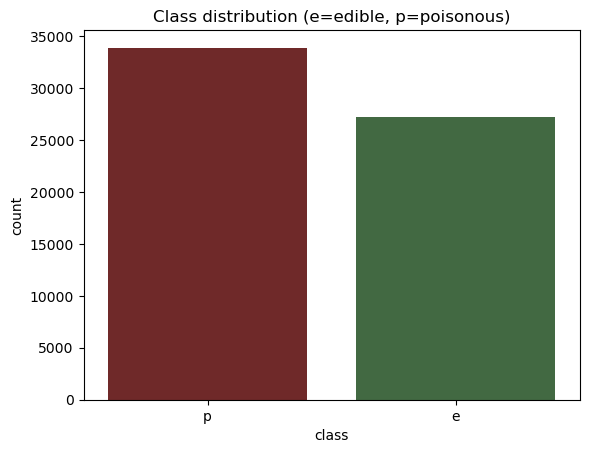

class
p    33888
e    27181
Name: count, dtype: int64


In [14]:
## To visually get rid of the warning: 
import warnings
warnings.filterwarnings('ignore')

# Visualizing the distribution of the target class using seaborn countplot
# Seeing for the class column how the distibution of the data is
sns.countplot(data=data, x='class', palette=['#7A1E1E', '#3B6F3C'])  # color palette source on how to change the colors: https://stackoverflow.com/questions/57417970/how-to-set-custom-colors-on-a-count-plot-in-seaborn
plt.title('Class distribution (e=edible, p=poisonous)')
plt.show()
print(data['class'].value_counts()) 

> From the countplot that represents the amount of edible mushrooms compared to the amount of poisonous mushrooms, it can be concluded that in this dataset there are more poisonous mushrooms than edible mushrooms.

### Looking at the relations between the class column and the different columns

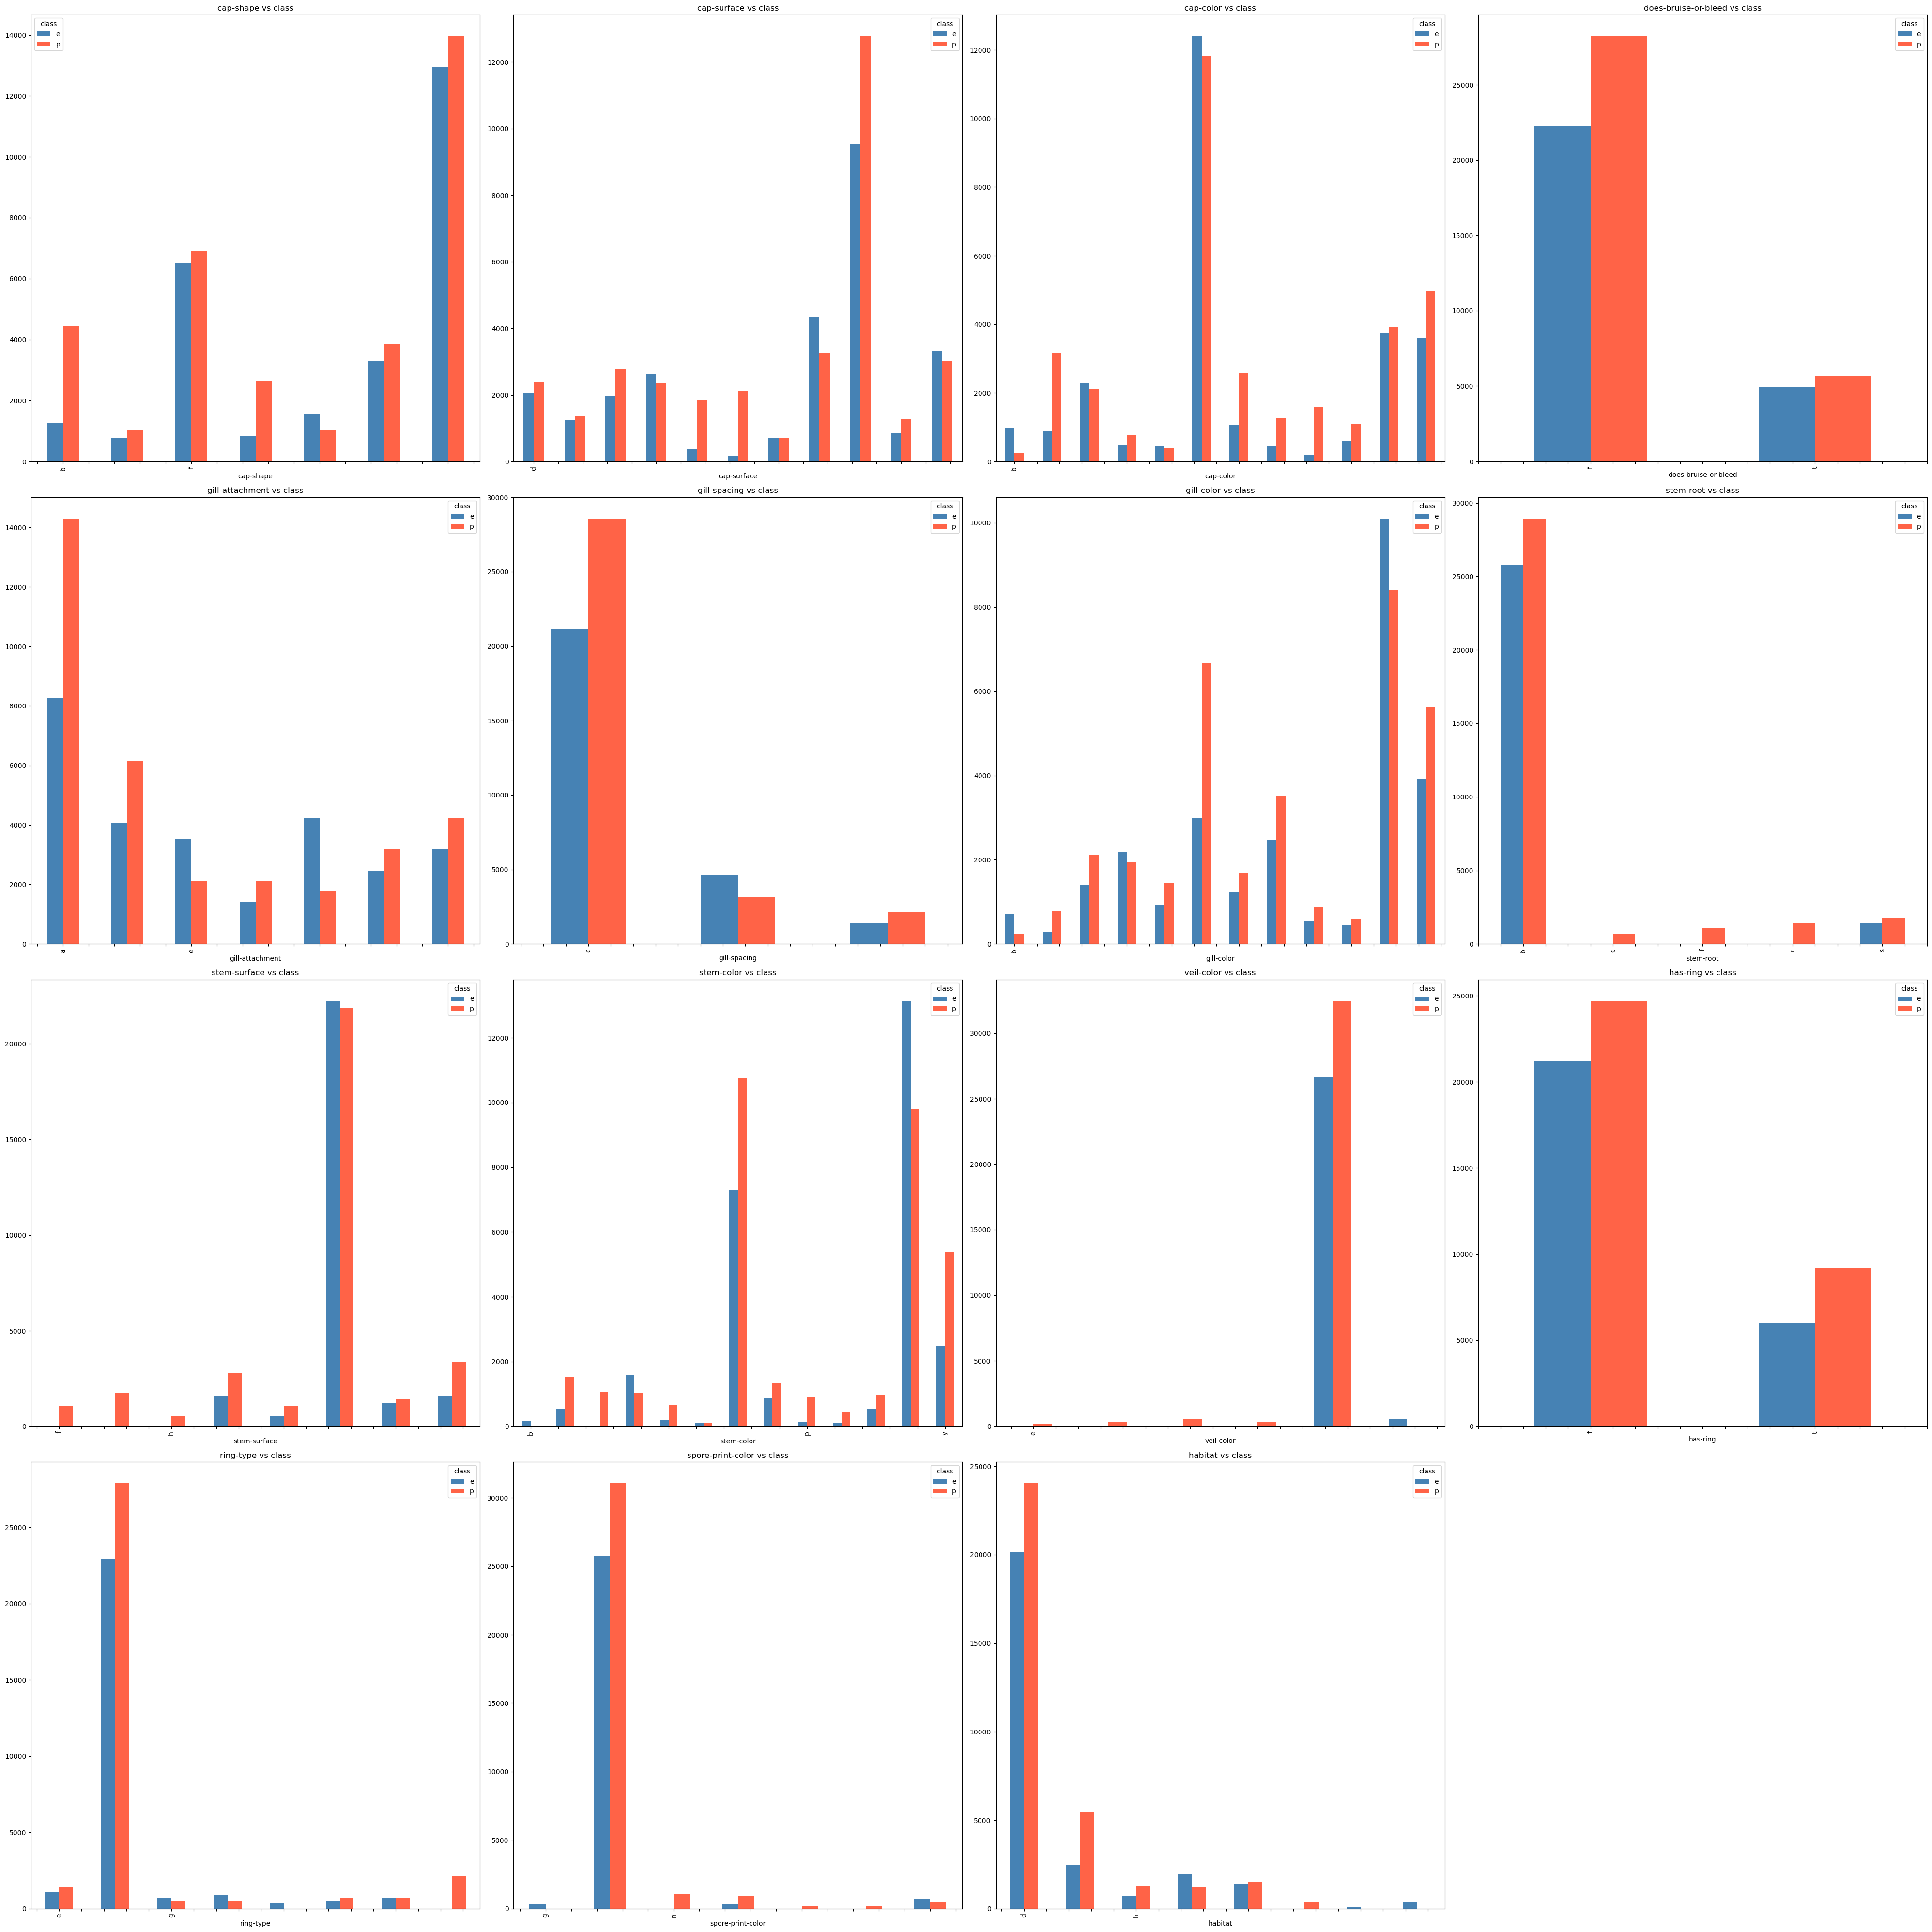

CPU times: user 2.9 s, sys: 1.45 s, total: 4.35 s
Wall time: 4.81 s


In [15]:
%%time
# Cross-tab bar charts for inspecting the key features vs class
features_to_test = ['cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 
                    'gill-spacing', 'gill-color', 'stem-root', 'stem-surface', 'stem-color', 
                    'veil-color', 'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season'] # these are only the categorical variables


fig, axes = plt.subplots(4, 4, figsize=(40, 40))           # figsize was chosen this big so that the labels and values on the axisses would be big enough to be readable
axes = axes.flatten()

for i, feat in enumerate(features_to_test ):
    ct = pd.crosstab(data[feat], data['class'])
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'tomato'])
    axes[i].set_title(f'{feat} vs class')
    axes[i].set_xlabel(feat)
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].xaxis.set_major_locator(plt.MaxNLocator(20))  # show maximum 20 tickmarcks (was used to solve an issue with the x-as of some plots)
    # Hide all unused subplots
for j in range(len(features_to_test), len(axes)):
    axes[j].set_visible(False)

axes[-1].set_visible(False)
plt.tight_layout()   # automatically adjusts the spacing between subplots to prevent overlap between ticks and labels
plt.show()

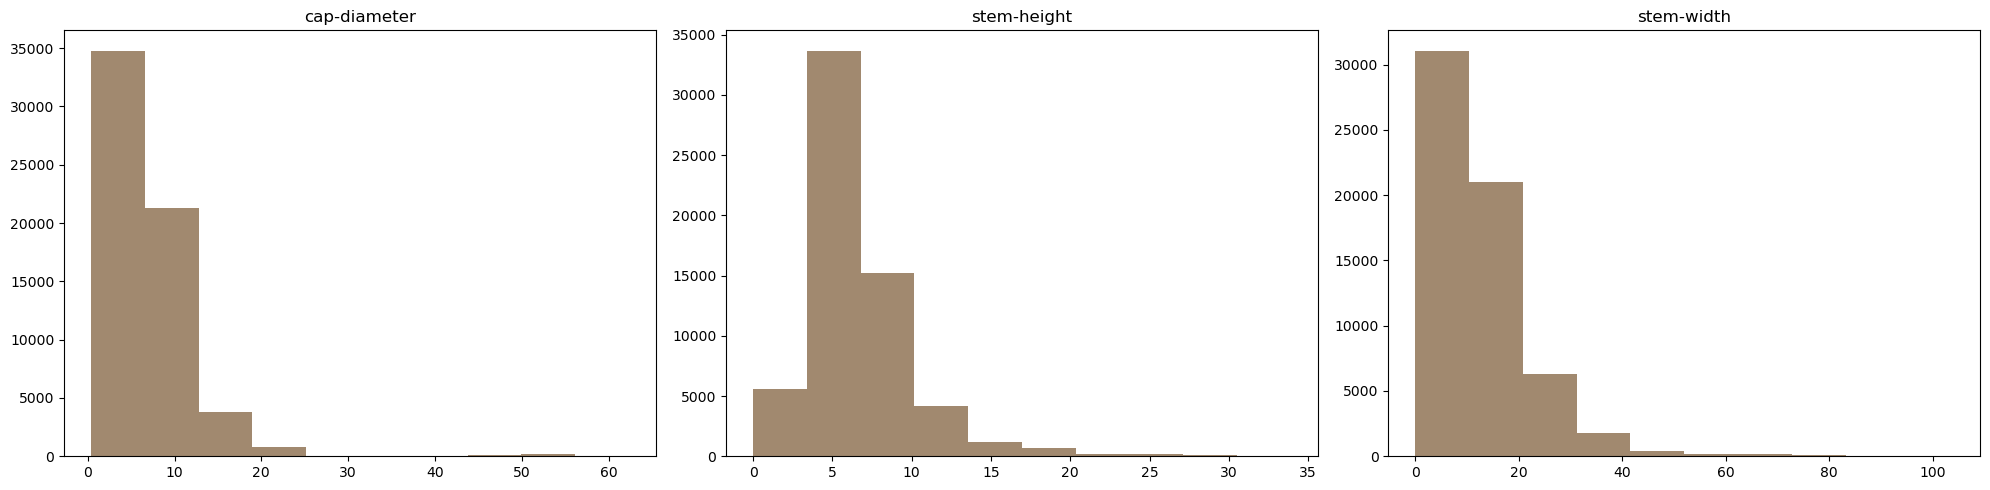

In [16]:
# Histogram overview of all feature columns (the numercial columns)
# df.hist() gives a quick overview of value distributions per column
# data.hist(figsize=(20, 10), grid=False, color = "forestgreen");
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, col in enumerate(numerical_columns):
    data[col].hist(ax=axes[i], grid=False, color="#A1896F") # I chose brown because a lot of mushrooms are brown 🍄‍🟫
    axes[i].set_title(col)

plt.tight_layout()
plt.show()
# Note: with all-categorical data these are bar charts over the encoded integer values

In [17]:
# Encode the target column with LabelEncoder: e=0, p=1
le = LabelEncoder()  # creating the labelencoder
y_encoded = pd.Series(le.fit_transform(data['class']), name='class') # encoding the target column
print(f"Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")  # printing the mapping
    ## zip -> pairs string and integer together   (bron: https://docs.python.org/3/library/functions.html#zip )
    ## dict() -> turns it into a readble diary    (bron: https://docs.python.org/3/library/stdtypes.html#dict )

# One-Hot Encode all feature columns
# drop_first=True removes one dummy per category to avoid the dummy-variable trap
feature_cols = [c for c in data.columns if c != 'class']   # selecting the feature columns
data_ohe = pd.get_dummies(data[feature_cols], drop_first=True)  # one hot encoding the features

# Combine everything into one encoded dataframe
data_encoded = pd.concat([y_encoded, data_ohe], axis=1)

print(f"Shape after OHE: {data_encoded.shape}")
print(f"  Original feature columns: {len(feature_cols)}")
print(f"  OHE feature columns     : {data_ohe.shape[1]}")
data_encoded.head()

Class mapping: {'e': np.int64(0), 'p': np.int64(1)}
Shape after OHE: (61069, 103)
  Original feature columns: 19
  OHE feature columns     : 102


,class,cap-diameter,stem-height,stem-width,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,...,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_s,season_u,season_w
0,1,15.26,16.95,17.09,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1,1,16.60,17.99,18.19,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
2,1,14.07,17.80,17.74,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
3,1,14.17,15.77,15.98,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,1,14.64,16.53,17.20,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True


### Looking at the correlation between the different possible identifiers

#### Heatmap showing the top 15 most correlated features

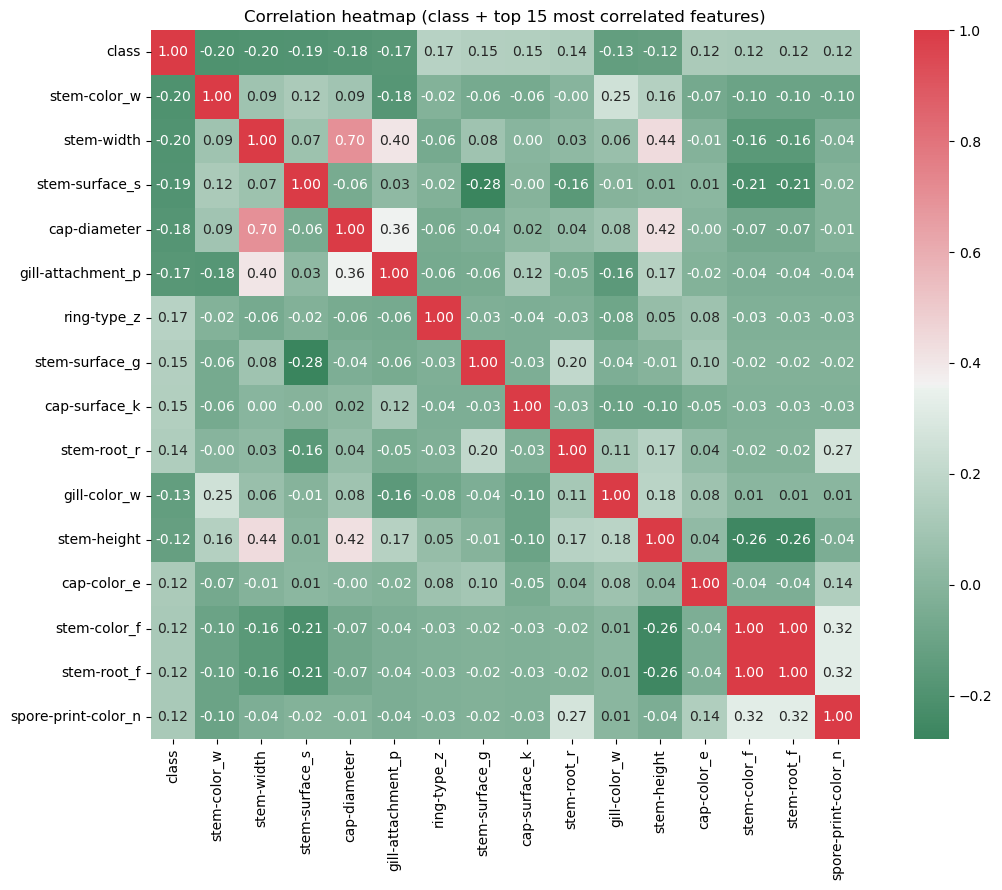

In [18]:
# Correlation heatmap — > shows top 15 (for readability) OHE features that are most correlated with class
corr_with_class = data_encoded.corr()['class'].drop('class').abs().sort_values(ascending=False)
top15_features = corr_with_class.head(15).index.tolist()

# Heatmap of correlations among top 15 features + class
f, ax = plt.subplots(figsize=(12, 9))
subset_corr = data_encoded[['class'] + top15_features].corr()
sns.heatmap(
    subset_corr,
    cmap=sns.diverging_palette(145, 10, as_cmap=True),
    mask=np.zeros_like(subset_corr, dtype=bool),
    square=True,
    annot=True,
    fmt='.2f',
    ax=ax
)
plt.title('Correlation heatmap (class + top 15 most correlated features)')
plt.tight_layout()
plt.show()

#### Plot showing the top 20 most correlated features & list of the top 15 most correlated features

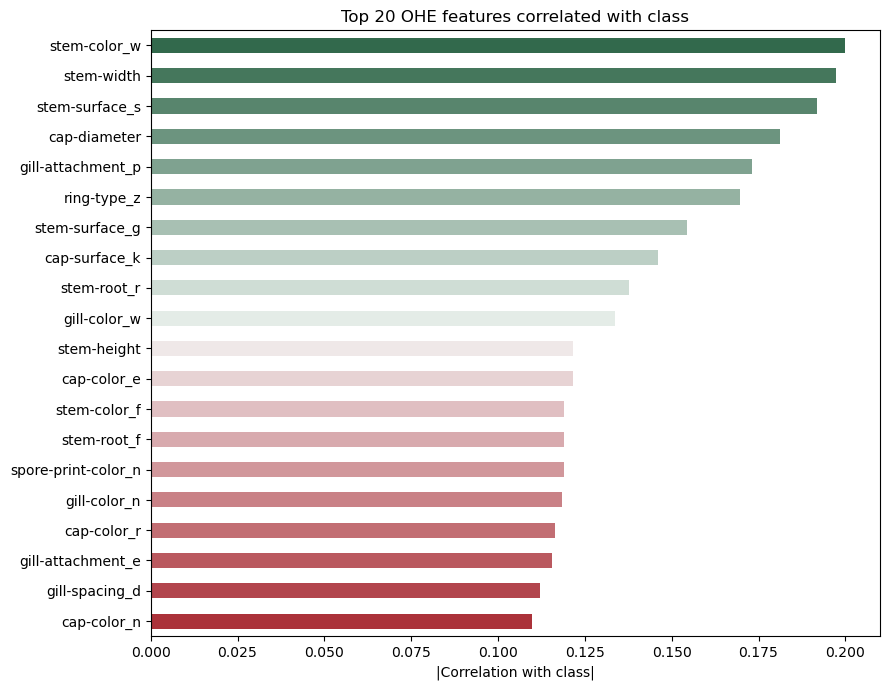

Top 15 OHE features correlated with class:
__________________________________________
stem-color_w           0.199979
stem-width             0.197368
stem-surface_s         0.191848
cap-diameter           0.181139
gill-attachment_p      0.173232
ring-type_z            0.169757
stem-surface_g         0.154504
cap-surface_k          0.145987
stem-root_r            0.137783
gill-color_w           0.133578
stem-height            0.121593
cap-color_e            0.121489
stem-color_f           0.118972
stem-root_f            0.118972
spore-print-color_n    0.118972
Name: class, dtype: float64


In [19]:
# Top 20 OHE features most correlated with class (using seaborn diverging palette)
corr_with_class = data_encoded.corr()['class'].drop('class').abs().sort_values(ascending=False)
top20 = corr_with_class.head(20)

f, ax = plt.subplots(figsize=(9, 7))
top20.sort_values().plot(kind='barh',
                         color = sns.diverging_palette(10, 145, s=70, l=40, n=20),  # creates a color palette that diverges from a neutral center outward in two directions (usefful for color gradients) (I chose a forestish kind of color scheme) (source = https://seaborn.pydata.org/tutorial/color_palettes.html#custom-diverging-palettes )
                         ax=ax)
ax.set_xlabel('|Correlation with class|')
ax.set_title('Top 20 OHE features correlated with class')
plt.tight_layout()
plt.show()

print("Top 15 OHE features correlated with class:")
print("__________________________________________")
print(corr_with_class.head(15))

>**Conclusion on feature correlations with class**:
>
>The top 3 most correlated OHE features with the class label are stem-color_w (0.199979), stem-width (0.197368), and stem-surface_s (0.191848). However, all 20 features shown have correlations below 0,20, which is considered weak.
This is a direct consequence of One-Hot Encoding, each original categorical feature gets split into multiple binary dummy columns, spreading the predictive signal across many columns. For example, the original stem-color column gets split into stem-color_w, stem-color_f, stem-color_e etc., each carrying only a fraction of the total information.
This means that the relationship between features and class is non-linear and combined. No single dummy column alone can predict edibility, but together they possibly can.
>This is why it is thought that tree-based models like Random Forest and Gradient Boosting will perform well with this data, because they can combine many weak OHE features across multiple splits to find the pattern, whereas a simple linear model like Logistic Regression struggles more when no single feature has a strong linear correlation with the target.

>**Pre-processing steps performed:**
>1. **🍄‍🟫 Dropping the non informative columns**
> A loop checks every column for columns with only 1 unique value. 'veil-type' was the only one found and got dropped automatically.
>
>2. **🍄‍🟫 Handling missing values**
> Two separate strategies were used for the different kinds of variables.
> Rather than using dropna() (which was tried but dropped too many rows), the columns were split into two groups and I imputed them differently to keep as much data as possible:
> - Categorical columns: filled with the most frequent value using SimpleImputer(strategy="most_frequent")
> - Numerical columns (cap-diameter, stem-height, stem-width): filled using KNNImputer(n_neighbors=3), which looks at the 3 most similar rows to estimate the missing value — better than just using the mean
>
>3. **🍄‍🟫 Target encoding**
> The class column (e/p) is encoded to integers using LabelEncoder (e=0, p=1).
>
>4. **🍄‍🟫 One-Hot Encoding (OHE)**
> All remaining feature columns are converted to binary (0/1) dummy columns using pd.get_dummies(drop_first=True).
>
>5. **🍄‍🟫 Looking into correlation between the columns and the class column**
> A heatmap, bar chart, and printed list are used to inspect which OHE features are most correlated with the class label.

---
## 🍄‍🟫 Part 5: Regression
> The goal of regression is to predict a continuous numeric value from a set of features. This mushroom dataset contains three real numeric columns: cap-diameter, stem-height and stem-width. Here cap-diameter is used as the regression target, predicted from all other features cap diameter was chosen because it is a biologically meaningful continuous measurement that is likely influenced by many other physical characteristics of the mushroom such as its habitat, season, and gill structure. 
>Four regression models are compared:
>
>1. **🍄‍🟫 Linear Regression** — the baseline
>2. **🍄‍🟫 Ridge (L2 regularization)** — penalises large coefficients to reduce overfitting
>3. **🍄‍🟫 Lasso (L1 regularization)** — like Ridge, but also zeroes out uninformative features
>4. **🍄‍🟫 Polynomial Features + Ridge** — adds degree-2 combinations of features to capture non-linear patterns
>
> For each model, both train and test metrics (**MAE**, **MSE**, **R²**) are reported side by side. 


In [20]:
# Regression target: cap-diameter (a real continuous numeric column)
# This is a numeric target ==> no label encoding needed :)
y_reg = data['cap-diameter'].reset_index(drop=True)
print(f"Target: cap-diameter")
print(f"  Min : {y_reg.min():.2f}")
print(f"  Max : {y_reg.max():.2f}")
print(f"  Mean: {y_reg.mean():.2f}")

# Features: all columns except 'class' and 'cap-diameter'
# OHE the categorical columns, keep the other numeric columns (stem-height, stem-width) as-is
reg_base_cols = [c for c in data.columns if c not in ['class', 'cap-diameter']] ## selecting the feature columns
X_reg = pd.get_dummies(data[reg_base_cols], drop_first=True)  ## One-Hot Encoding the features

print(f"\nFeature matrix shape (rows, columns): {X_reg.shape}")

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=7)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Target: cap-diameter
  Min : 0.38
  Max : 62.34
  Mean: 6.73

Feature matrix shape (rows, columns): (61069, 101)
Train: (48855, 101), Test: (12214, 101)


In [21]:
# Scale features
# StandardScaler: mean=0, std=1 —> not much affected by outliers (= prefererd ==> chosen to use for this reason )
scaler_reg = StandardScaler()
# scaler_reg = MinMaxScaler()   # scales to [0, 1], sensitive to outliers
# scaler_reg = RobustScaler()   # uses IQR, most robust to outliers

# IMPORTANT: we fit ONLY on the training set, then transform both training and test set (to avoid data leakage)
X_train_reg_sc = scaler_reg.fit_transform(X_train)
X_test_reg_sc  = scaler_reg.transform(X_test)

In [22]:
## To define a function that always prints the results of the Regression the same way 
def eval_regression(model, X_train, X_test, y_train, y_test):   # defining the function
    """Fit and print train vs test metrics side by side to detect over/underfitting."""   # for reproducibility: a note of what this fucntion does
    model.fit(X_train, y_train)  # fitting the model on the training data
    y_train_pred = model.predict(X_train)  # predicting on the training data  (to detect overfitting)
    y_test_pred = model.predict(X_test)    # predicting on the test data (to test how good the model is)
    print(f"        Metric | train  | test")
    print(f"--------------------------------")
    print(f"           MAE | {mean_absolute_error(y_train, y_train_pred):.4f} | {mean_absolute_error(y_test, y_test_pred):.4f}")
    print(f"           MSE | {mean_squared_error(y_train, y_train_pred):.4f} | {mean_squared_error(y_test, y_test_pred):.4f}")
    print(f"            R2 | {r2_score(y_train, y_train_pred):.4f} | {r2_score(y_test, y_test_pred):.4f}")
    print(f"Score of model | {model.score(X_train, y_train):.4f} | {model.score(X_test, y_test):.4f}")
    return r2_score(y_test, y_test_pred)   ## return the R² score as a number (so it can be stored in a variable to use in the summary table)

### Model 1: Linear Regression (baseline)

In [23]:
%%time
# Model 1: Linear Regression (baseline)
print("=== Model 1: Linear Regression ===")
print("__________________________________")
r2_lr = eval_regression(LinearRegression(), X_train, X_test, y_train, y_test) 
# using the newly defined eval_regression function and storing the result of the linear regression in r2_lr so it can be used in the summary later 

=== Model 1: Linear Regression ===
__________________________________
        Metric | train  | test
--------------------------------
           MAE | 1.7450 | 1.7307
           MSE | 7.2115 | 6.9882
            R2 | 0.7428 | 0.7358
Score of model | 0.7428 | 0.7358
CPU times: user 923 ms, sys: 608 ms, total: 1.53 s
Wall time: 704 ms


### Model 2: Ridge (L2 regularization)

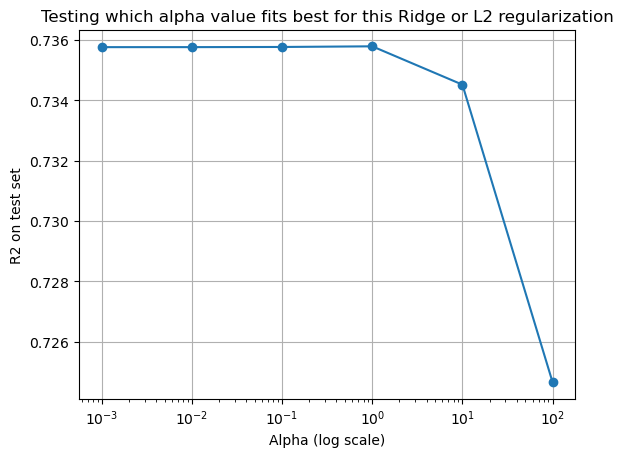

Best Ridge alpha: 1



=== Model 2: Ridge (alpha=1) ===
____________________________________________________
        Metric | train  | test
--------------------------------
           MAE | 1.7450 | 1.7307
           MSE | 7.2115 | 6.9882
            R2 | 0.7428 | 0.7358
Score of model | 0.7428 | 0.7358
CPU times: user 1.33 s, sys: 330 ms, total: 1.66 s
Wall time: 1.01 s


In [24]:
%%time
# Model 2: Ridge (L2 regularization) (sweep alpha values)
alphas = [0.001, 0.01, 0.1, 1, 10, 100]  # Defining the alpha values that will be tested for the L2 regularization as a method of optimalisation
r2_ridge_scores = []  # creating an empty list to store the scores in later
# to make this easier and faster, I created a loop to go through the different alphas that I specified 
for a in alphas:
    m = Ridge(alpha=a)  # creating a ridge model with the alpha value that wll be tested
    m.fit(X_train, y_train)  #fitting (or training) ONLY on the training data 
    r2_ridge_scores.append(r2_score(y_test, m.predict(X_test))) # predicting on the test data so we can compare the scores (shown in plot)
        # append so that they all get shon in 1 plot (makes it easier to compare the results and then to conclude what alpha value is best)
plt.figure()
plt.semilogx(alphas, r2_ridge_scores, marker='o') # semilogx is used instead of a normal plot because the alpha values span very different scales (0.001 to 100), so a log scale on the x-axis spaces them out evenly and makes the chart readable
# bron voor semilogx: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.semilogx.html
plt.xlabel('Alpha (log scale)')
plt.ylabel('R2 on test set')
plt.title('Testing which alpha value fits best for this Ridge or L2 regularization')
plt.grid(True)
plt.show()

best_alpha_ridge = alphas[np.argmax(r2_ridge_scores)]  # finding the index that is linked to the highest R² score in te list we created
# so that the best scoring alpha value gets used for further regularization and comparison with other tests
print(f"Best Ridge alpha: {best_alpha_ridge}")
print("\n")
print(f"\n=== Model 2: Ridge (alpha={best_alpha_ridge}) ===")
print("____________________________________________________")
r2_ridge = eval_regression(Ridge(alpha=best_alpha_ridge), X_train_reg_sc, X_test_reg_sc, y_train, y_test) # training and evaluating the final Ridge model + stroing it in r2_ridge to use in summary llater

### Model 3: Lasso (L1 regularization)

In [25]:
%%time
# Model 3: Lasso (L1 regularization) (automatic feature selection)
print("=== Model 3: Lasso (alpha=0,01) ===")
print("___________________________________")

lasso = Lasso(alpha=0.01)   # creating a lasso model with alpha chosen as 0,01
r2_lasso = eval_regression(lasso, X_train_reg_sc, X_test_reg_sc, y_train, y_test)  # training and evaluating the model + storing it so we can compare the models easier later

=== Model 3: Lasso (alpha=0,01) ===
___________________________________
        Metric | train  | test
--------------------------------
           MAE | 1.7268 | 1.7104
           MSE | 7.2646 | 7.0228
            R2 | 0.7409 | 0.7345
Score of model | 0.7409 | 0.7345
CPU times: user 981 ms, sys: 540 ms, total: 1.52 s
Wall time: 457 ms


### Model 4: Polynomial Features (degree=2) + Ridge

In [26]:
%%time
# Model 4: Polynomial Features (degree=2) + Ridge
# Higher-order features capture non-linear relationships between features
poly = PolynomialFeatures(degree=2, include_bias=False)  # creating the PolynomialFeatures object
X_train_poly = poly.fit_transform(X_train_reg_sc)  # Fit and transforming the training data
X_test_poly  = poly.transform(X_test_reg_sc)   # ONLY transforming the test data 
print(f"Shape (rows,cols) after degree-2 polynomial expansion: {X_train_poly.shape}") # printing to see how much the rows and columns expanded

print(f"\n=== Model 4: Polynomial (degree=2) + Ridge ===")
print("_______________________________________________")
r2_poly = eval_regression(Ridge(alpha=best_alpha_ridge), X_train_poly, X_test_poly, y_train, y_test) # training and evaluating the model + storing the result in r2_poly to make comparing the resolts easier by making use of a summary

Shape (rows,cols) after degree-2 polynomial expansion: (48855, 5252)

=== Model 4: Polynomial (degree=2) + Ridge ===
_______________________________________________
        Metric | train  | test
--------------------------------
           MAE | 0.6343 | 0.6489
           MSE | 0.9295 | 1.0122
            R2 | 0.9668 | 0.9617
Score of model | 0.9668 | 0.9617
CPU times: user 45.8 s, sys: 3min 43s, total: 4min 28s
Wall time: 3min 8s


### 🍄 Regression summary 🍄

In [27]:
# Regression summary to get an easier overview to compare the results of the different regression models
## Creating a dataframe for the summary of the different regression types tested with a model and an R² column
reg_summary = pd.DataFrame({
    'Model': ['Linear Regression', f'Ridge (alpha={best_alpha_ridge})', 'Lasso (alpha=0.01)', 'Poly(2)+Ridge'],
    'R2 (test)': [r2_lr, r2_ridge, r2_lasso, r2_poly]
})  

print("=== Regression Summary ===")
print("__________________________")

reg_summary.sort_values('R2 (test)', ascending=False) # sorting the results based on the highest R² score and placing the highest R² score at the top with ascending = False

=== Regression Summary ===
__________________________


,Model,R2 (test)
3,Poly(2)+Ridge,0.961727
1,Ridge (alpha=1),0.735760
0,Linear Regression,0.735759
2,Lasso (alpha=0.01),0.734451


> **🍄 Regression conclusions:**
> 
> All four models achieve a decent R² score, meaning the other mushroom characteristics do explain a meaningful portion of the variation in cap diameter.
> Linear Regression and Ridge (alpha=1) score almost identically at around 0.73576, which makes sense because Ridge only differs from Linear Regression when overfitting is present, and with a small alpha of 1 the regularisation effect is minimal. Lasso scores slightly lower at 0.734451, likely because it zeroed out some features that still carried a small amount of useful information.
> The standout result is Polynomial Features + Ridge, which is closest to one with a score of 0.961727. This shows that the relationship between the features and cap diameter is largely non-linear, because the degree-2 combinations of features capture patterns that the linear models miss entirely.
> However, it is worth being cautious about the Polynomial model. A score this much higher than the linear models could indicate overfitting, the model may be fitting noise in the training data rather than a genuine pattern. Comparing train vs test scores for this model is important because of this and after comparing the scores for the training and the test set it can be concluded thath due to only small differences between the values, no overfitting has taken place.

---
## 🍄‍🟫 Part 6: Classification

> The goal of classification is to predict which category a sample belongs to. For this dataset the question is straightforward: can the physical characteristics of a mushroom tell us whether it is edible or poisonous?
> This is a binary classification problem, because the target has two possible values: edible (0) and poisonous (1). But this will be quickly taken care of using a one hot encoder.
>
> Six different classifiers are trained and compared:
> 
>1. **🍄‍🟫 Logistic Regression:** a simple but effective linear classifier, trained via a sklearn Pipeline and tuned with RandomizedSearchCV
>2. **🍄‍🟫 Multinomial Naive Bayes:** well suited for binary OHE features (all 0s and 1s)
>3. **🍄‍🟫 Gaussian Naive Bayes:** assumes a normal distribution per feature, trained via a Pipeline
>4. **🍄‍🟫 Decision Tree:** learns a sequence of if/else splits, visualised with plot_tree and tuned with GridSearchCV
>5. **🍄‍🟫 Random Forest:** combines many decision trees via bagging, tuned with GridSearchCV
>6. **🍄‍🟫 Gradient Boosting & AdaBoost:** sequential ensemble methods that build trees one by one, each correcting the mistakes of the previous one
>
> For each model both train and test accuracy are reported to detect over- or underfitting. A confusion matrix and ROC curve are shown for every classifier, and all ROC curves are compared in a single overlay plot at the end.

In [28]:
# Creating features and targets for classification
X_cls = data_encoded.drop('class', axis=1)  # OHE binary features
y_cls = data_encoded['class']               # 0=edible, 1=poisonous  --> target vector

# Creating the train-test split (the data is balanced)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=7)

print(f"Train: {X_train_c.shape}, Test: {X_test_c.shape}") # printing the amount of rows and columns that there are in each split (checking if same number of columns for both)
print(f"Class distribution in test: {pd.Series(y_test_c).value_counts().to_dict()}")   # printing the class distribution to visually check the balance

Train: (48855, 102), Test: (12214, 102)
Class distribution in test: {1: 6749, 0: 5465}


In [29]:
## To define a function to be able to compare the classifiers easier 
def evaluate_classifier(model, X_train, X_test, y_train, y_test, name='Model', show_roc=True):
    """Fit, evaluate, show confusion matrix, and optionally ROC curve."""
    model.fit(X_train, y_train) #Fitting only on the training data
    y_pred    = model.predict(X_test)  # predicting on the test set
    acc_train = accuracy_score(y_train, model.predict(X_train))  # calculating and printing the accuracy score on the training set
    acc_test  = accuracy_score(y_test,  y_pred)   # calculating and printing the accuracy score on the test set

    print(f"\n{'='*55}")
    print(f"=== {name} ===")
    print("_" * (len(name) + 8)) # to print the line the same length as the header (tried with knowledge from python & HTML course)
    print(f"Accuracy on the training set: {acc_train:.4f}") # printing the accuracy score on the training set (4 decimals)
    print(f"Accuracy on the test set    : {acc_test:.4f}") #  printing the accuracy score on the test set (4 decimals)
    # To detect over- or underfitting so that this can be altered if needed
    if acc_train - acc_test > 0.02:
        print("  => Possible OVERFITTING (train >> test)")
    elif acc_train < 0.8 and acc_test < 0.8:
        print("  => Possible UNDERFITTING (both low)")
    print("="*55)
    print(classification_report(y_test, y_pred, target_names=['edible', 'poisonous']))  # prints the classification report

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred) # creating the confusion matrix
    disp = ConfusionMatrixDisplay(cm, display_labels=['edible', 'poisonous'])  # turning the confusion matrix into a plot ; bron: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html
    fig, ax = plt.subplots(figsize=(4, 4))  # to set the size of the subplots
    disp.plot(ax=ax, colorbar=False)  # removes the color scale bar (because otherwise it errors and shows an empty plot)
    ax.set_title(f'Confusion Matrix: {name}')  # to alter the name of each plot so it fits the classication model 
    plt.show()

    # ROC curve (create it if mentioned/wanted (so that it is only shown on the classification models and not on the method that was used to try and improve the model)
    if show_roc and hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, probs)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(5, 4))
        plt.title(f'ROC Curve: {name}')
        plt.plot(fpr, tpr, 'b', label=f'AUROC = {roc_auc:.2f}')
        plt.plot([0, 1], [0, 1], 'r--')
        plt.xlim([0, 1]); plt.ylim([0, 1])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc='lower right')
        plt.show()

    return acc_test  # return the accuracy of the test

### Classifier 1: Logistic Regression


=== Logistic Regression (using a Pipeline) ===
______________________________________________
Accuracy on the training set: 0.8408
Accuracy on the test set    : 0.8476
              precision    recall  f1-score   support

      edible       0.82      0.84      0.83      5465
   poisonous       0.87      0.85      0.86      6749

    accuracy                           0.85     12214
   macro avg       0.85      0.85      0.85     12214
weighted avg       0.85      0.85      0.85     12214



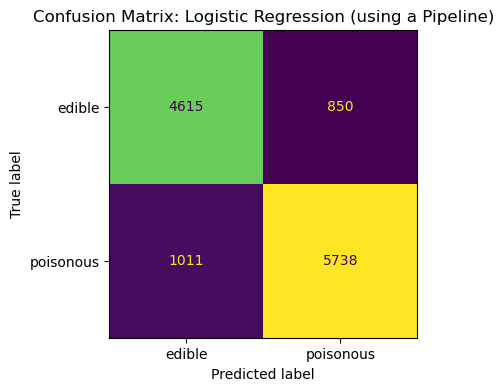

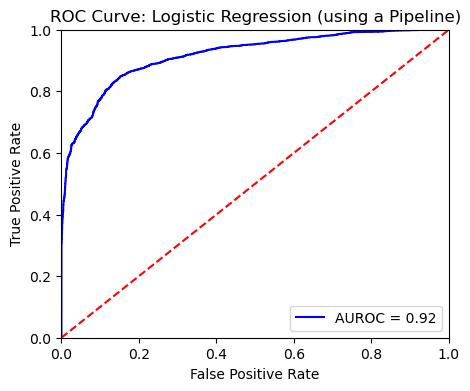

CPU times: user 4.54 s, sys: 23.8 ms, total: 4.56 s
Wall time: 2.96 s


In [30]:
%%time
# --- Classifier 1: Logistic Regression via Pipeline ---
# Pipeline: StandardScaler & LogisticRegression
# The Pipeline ensures the scaler is fitted on training data only (because we never fit on test data)

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=7)) # I chose random state = 7 for everything (to make it more reproducible) (7 used to be my lucky number)
])

acc_lr = evaluate_classifier(
    pipe_lr, X_train_c, X_test_c, y_train_c, y_test_c,
    'Logistic Regression (using a Pipeline)', show_roc=True
)   # training and evaluating the training set + show_roc to show the ROC curve

#### Logistic Regression hyperparameter tuning: RandomizedSearchCV 

In [31]:
%%time
# --- Logistic Regression hyperparameter tuning: RandomizedSearchCV ---
# RandomizedSearchCV samples n_iter combinations from distributions faster than GridSearchCV
# for continuous parameters like C
# (Here I typed some extra explenations (of extra tussenstappen) to make it clear for myself and to keep it clear to myself what I did and why)

# creating the basic pipeline = same as code block before this
base_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=5000, random_state=7))
])

# defining the search space for the hyperparameters
param_dist_lr = {
    'model__C':      uniform(0.01, 20),           # uniform distribution between 0,01 and 20 (this changes the strength of Logistic Regression)
    'model__solver': ['liblinear', 'saga', 'lbfgs'],  # model_solver = lgorithm used to optimise the model    & there are 3 options tested here
}

# creating the RandomizedSearchCV object
random_lr = RandomizedSearchCV(
    estimator=base_lr, # specificies the pipeline to finetune
    param_distributions=param_dist_lr, # defines the paramaeters to test 
    n_iter=30,  # tries 30 different combinations
    cv=5, # cross validation 5 fold (each combination is tested on 5 different splits and then average of the scores)
    scoring='balanced_accuracy', # specifying the scoring mechanism, this balanced_accuracy option is chosen to account for any class imbalance
    n_jobs=-1,  # uses all available CPU cores to run combinations in parallel, speeding up the search (because it was slow without this) 
    random_state=7  # improving reproducibilty
)

random_lr.fit(X_train_c, y_train_c)  # fitting the RandomizedSearchCV on training set 

print(f"Best params : {random_lr.best_params_}")  # prints the parameter that scored the best
print(f"Best CV score: {random_lr.best_score_:.4f}")   # together means: display this variable as a fixed-point float with exactly 4 digits after the decimal point (bronnen: https://docs.python.org/3/library/string.html#format-specification-mini-language  &  https://realpython.com/python-format-mini-language/ 

acc_lr_tuned = accuracy_score(y_test_c, random_lr.predict(X_test_c))   # storing in a variable to make it easier to use in the summary + getting the accuracy scores
print(f"Test accuracy (tuned LR): {acc_lr_tuned:.4f}")  # printing the accuracy scores (4 decimals)

Best params : {'model__C': np.float64(6.389444515468064), 'model__solver': 'liblinear'}
Best CV score: 0.8396
Test accuracy (tuned LR): 0.8474
CPU times: user 12 s, sys: 0 ns, total: 12 s
Wall time: 18min 43s


### Classifier 2: Naive Bayes 
Split up into 2a for Multinomial Naive Bayes
and 2b for Gaussian Naive Bayes

### Classifier 2a: Multinomial Naive Bayes


=== Multinomial Naive Bayes ===
_______________________________
Accuracy on the training set: 0.7589
Accuracy on the test set    : 0.7599
  => Possible UNDERFITTING (both low)
              precision    recall  f1-score   support

      edible       0.74      0.72      0.73      5465
   poisonous       0.78      0.79      0.79      6749

    accuracy                           0.76     12214
   macro avg       0.76      0.76      0.76     12214
weighted avg       0.76      0.76      0.76     12214



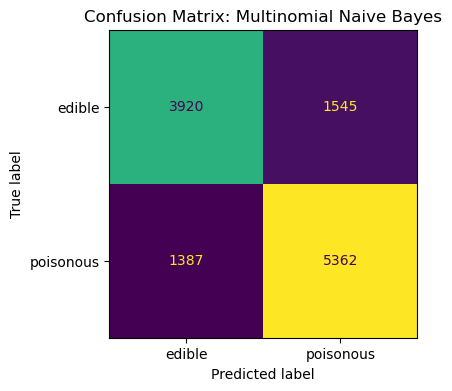

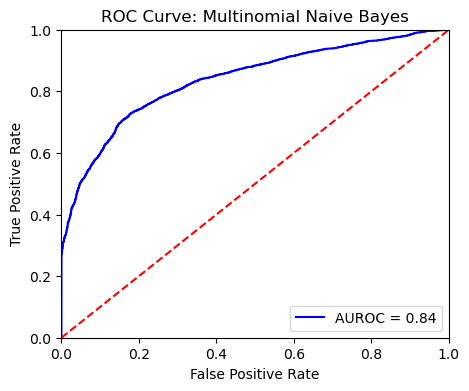

CPU times: user 1.26 s, sys: 0 ns, total: 1.26 s
Wall time: 985 ms


In [32]:
%%time
from sklearn.naive_bayes import MultinomialNB          # Naive bayes model
# --- Classifier 2a: Multinomial Naive Bayes ---
# MultinomialNB is well-suited for binary/count features & the OHE data is all 0s and 1s (binary) => this is why this is tested

model = MultinomialNB(alpha=1)  # creating the MultinomialNB model with alpha specified as 1

# training and evaluating the multinomial model
acc_modelMNB = evaluate_classifier(
    model, # the model specified above
    X_train_c.values, X_test_c.values, y_train_c, y_test_c,
    'Multinomial Naive Bayes',   # the name that will be added in the plots etc
    show_roc=True # to show the ROC curve
)


### Classifier 2b: Gaussian Naive Bayes


=== Gaussian Naive Bayes (Pipeline) ===
_______________________________________
Accuracy on the training set: 0.5852
Accuracy on the test set    : 0.5925
  => Possible UNDERFITTING (both low)
              precision    recall  f1-score   support

      edible       0.52      1.00      0.69      5465
   poisonous       0.99      0.26      0.42      6749

    accuracy                           0.59     12214
   macro avg       0.76      0.63      0.55     12214
weighted avg       0.78      0.59      0.54     12214



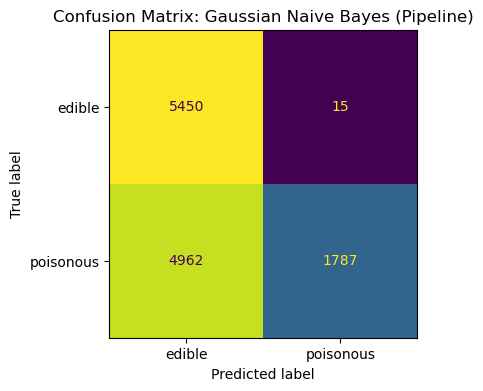

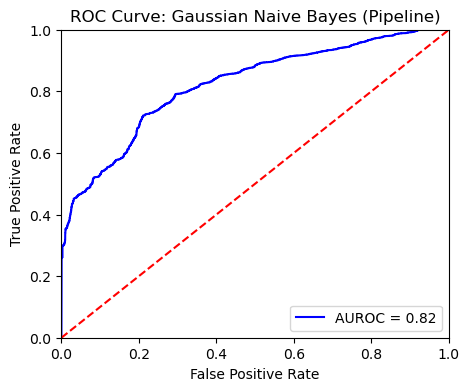

CPU times: user 803 ms, sys: 0 ns, total: 803 ms
Wall time: 883 ms


In [33]:
%%time
# --- Classifier 2b: Gaussian Naive Bayes (via Pipeline with scaling) ---
# here it was opted to use the default settings (which means that tthere will be no parameters specified)
# pipeline = made in the same way as with classifier 2a but then now with model specified as GuassianNB
pipe_gnb = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  GaussianNB())  # to specify the GuassianNB model to be used
])

# same as before in classifier 2a but specified to this Gaussian Naive Bayes model
acc_gnb = evaluate_classifier(
    pipe_gnb, X_train_c, X_test_c, y_train_c, y_test_c,
    'Gaussian Naive Bayes (Pipeline)', 
    show_roc=True
)

**Naive Bayes comparison:** I expected MultinomialNB to be better suited for binary feature data then the Gaussian Naive Bayes, but I was proven wrong when looking at the accuracy values.

### Classifier 3: Decision Tree


=== Decision Tree (default) ===
_______________________________
Accuracy on the training set: 1.0000
Accuracy on the test set    : 0.9990
              precision    recall  f1-score   support

      edible       1.00      1.00      1.00      5465
   poisonous       1.00      1.00      1.00      6749

    accuracy                           1.00     12214
   macro avg       1.00      1.00      1.00     12214
weighted avg       1.00      1.00      1.00     12214



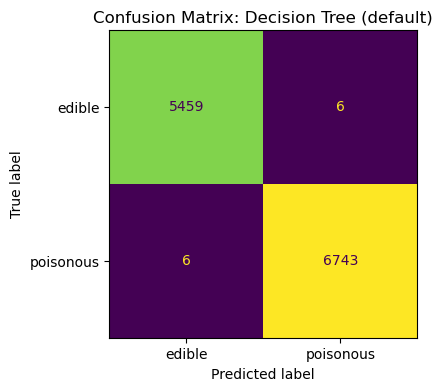

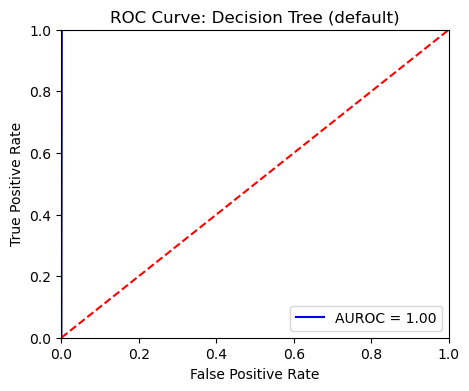

CPU times: user 1.13 s, sys: 0 ns, total: 1.13 s
Wall time: 1.19 s


In [34]:
%%time
# --- Classifier 3: Decision Tree (default) ---

dt_model = DecisionTreeClassifier(random_state=7)

# same as before in classifier 2a but specified to this DecisionTreeClassifier model
acc_dt = evaluate_classifier(
    dt_model, 
    X_train_c.values, X_test_c.values, y_train_c, y_test_c,
    'Decision Tree (default)',
    show_roc=True
)

#### Decision Tree: GridSearchCV hyperparameter tuning

In [35]:
%%time
# --- Decision Tree: GridSearchCV hyperparameter tuning ---

# defining the  hyperparameter grid
param_grid_dt = {
    'max_depth':         [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'criterion':         ['gini', 'entropy']
}

# creatting the GridSearchCV object
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=7), 
    param_grid_dt,
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_dt.fit(X_train_c, y_train_c) # running the search

# printing best parametters, best acccuracy and best estimator
print(f"Best DT params  : {grid_dt.best_params_}")
print(f"Best CV accuracy: {grid_dt.best_score_:.4f}")
print(f"Best estimator  : {grid_dt.best_estimator_}")

acc_dt_tuned = accuracy_score(y_test_c, grid_dt.best_estimator_.predict(X_test_c))  # evaluating in the test set

print(f"Test accuracy (tuned DT): {acc_dt_tuned:.4f}") # printing the test accuracy

Best DT params  : {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 5}
Best CV accuracy: 0.9984
Best estimator  : DecisionTreeClassifier(min_samples_split=5, random_state=7)
Test accuracy (tuned DT): 0.9989
CPU times: user 1.09 s, sys: 0 ns, total: 1.09 s
Wall time: 12.9 s


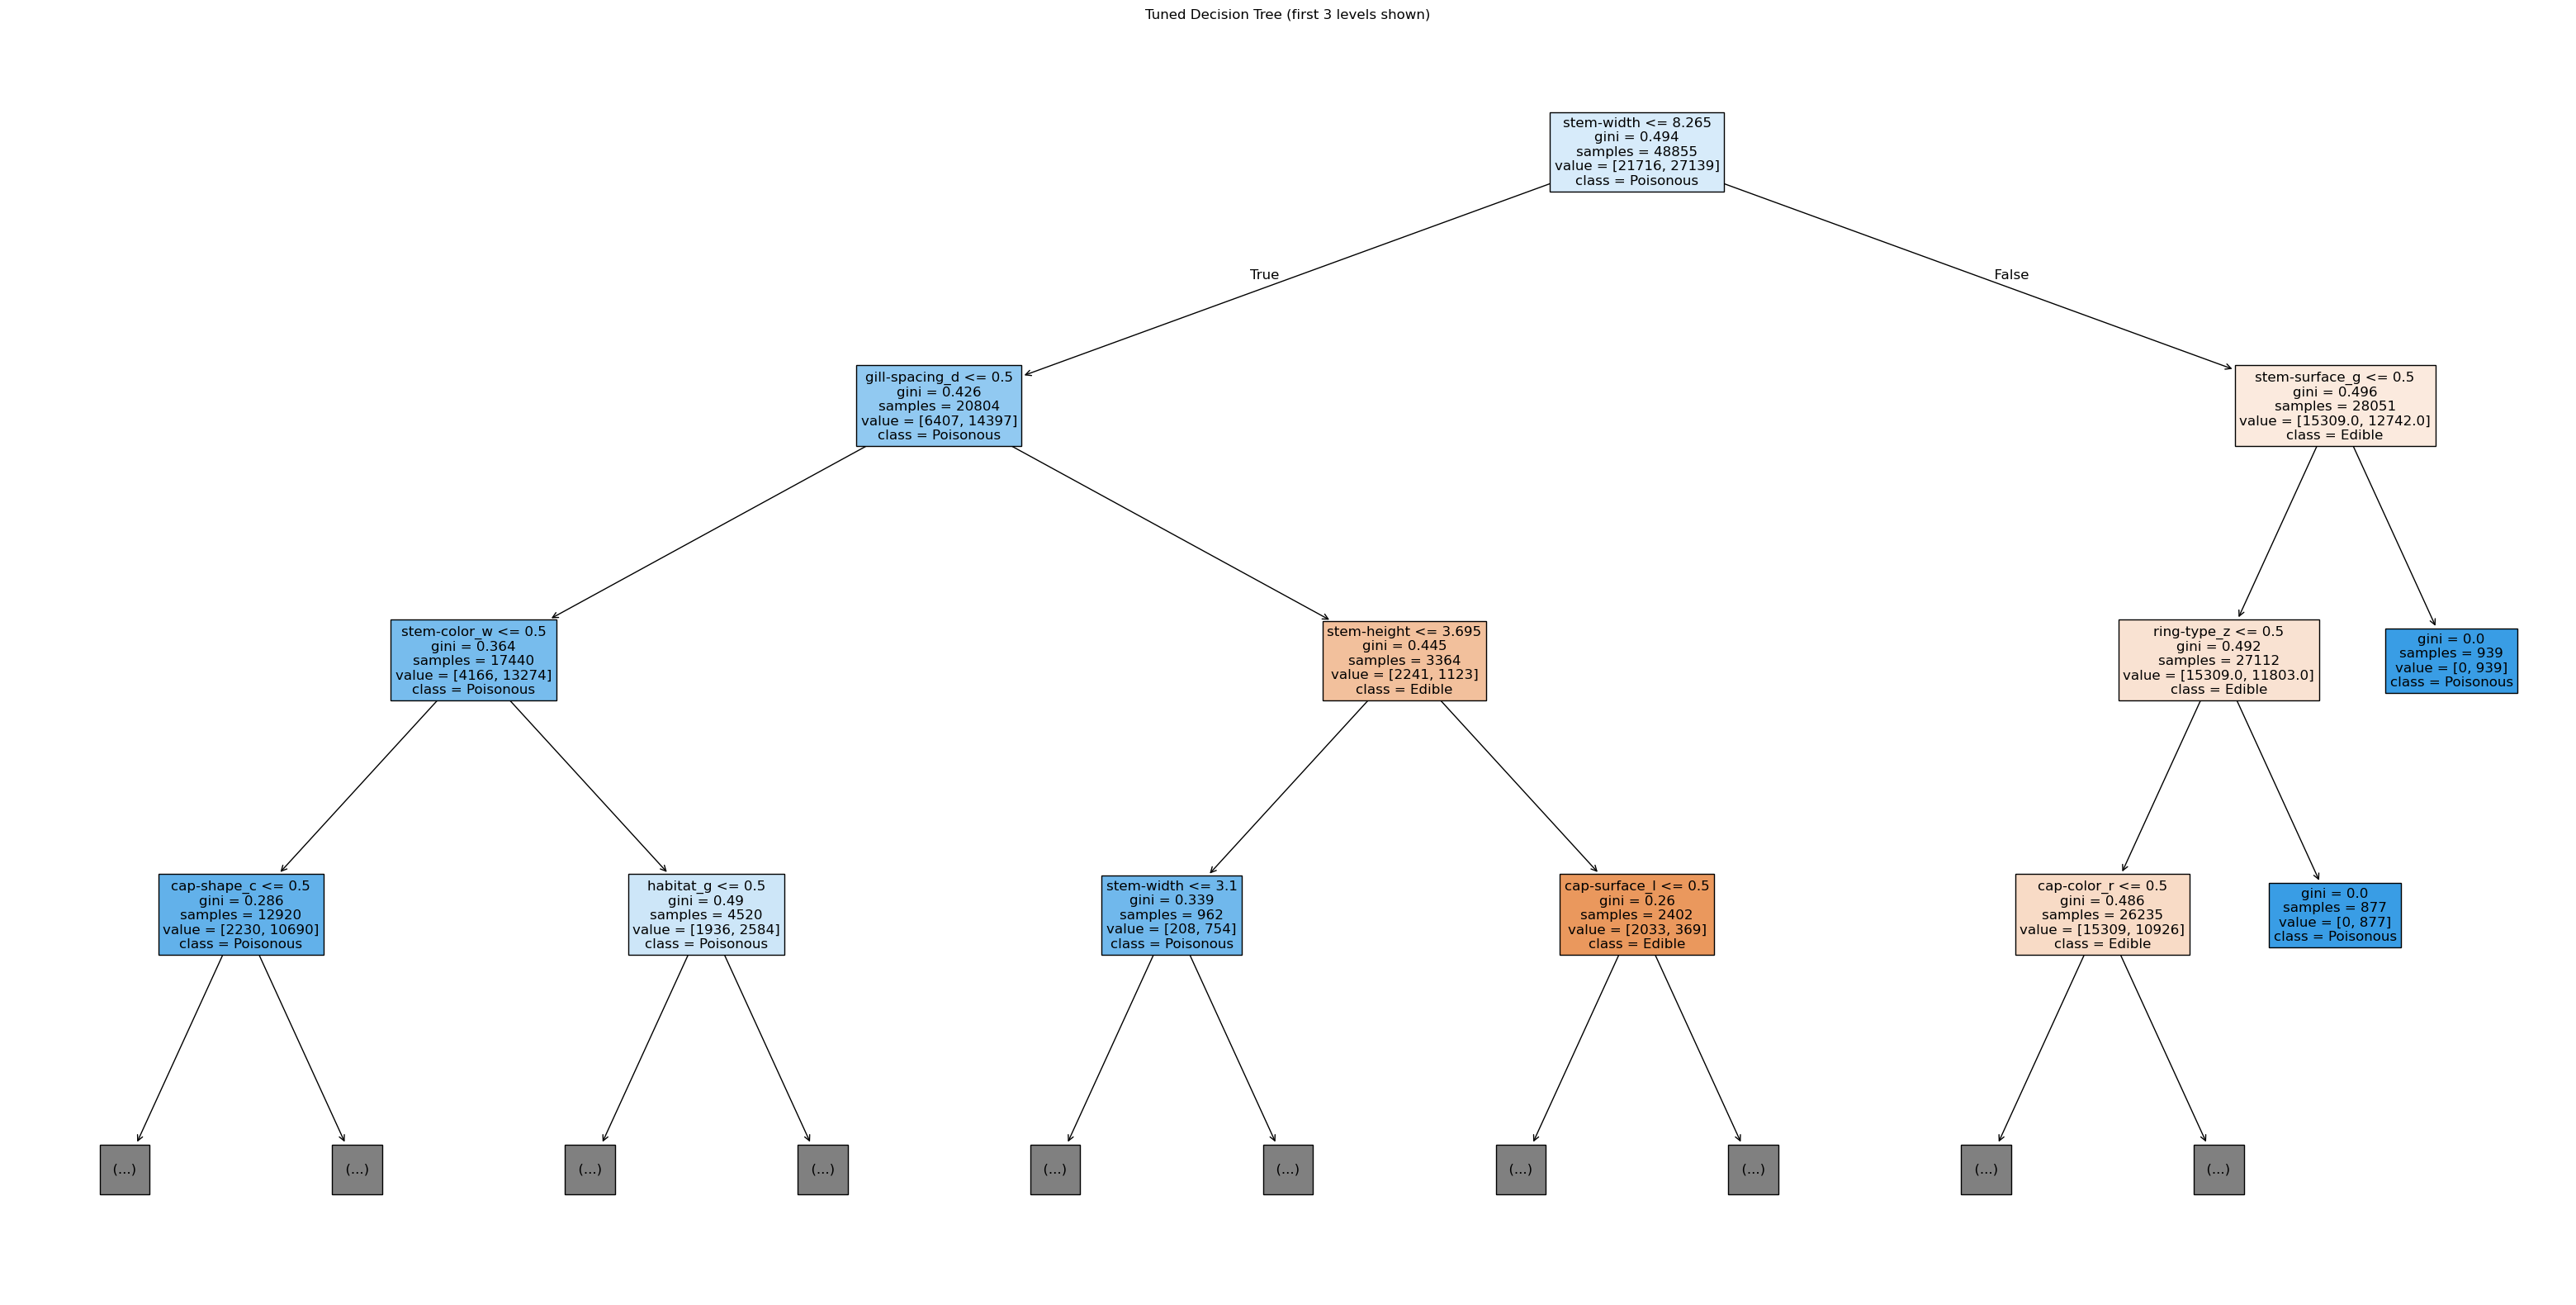

In [36]:
# Visualise the tuned Decision Tree (first 3 levels for readability)
fig = plt.figure(figsize=(40, 20))
ax = fig.add_subplot(1, 1, 1)

_= plot_tree(
    grid_dt.best_estimator_,
    max_depth=3,
    feature_names=list(X_cls.columns),
    class_names=['Edible', 'Poisonous'],
    filled=True, 
    fontsize=12, 
    ax=ax
)

plt.title('Tuned Decision Tree (first 3 levels shown)')
plt.show()

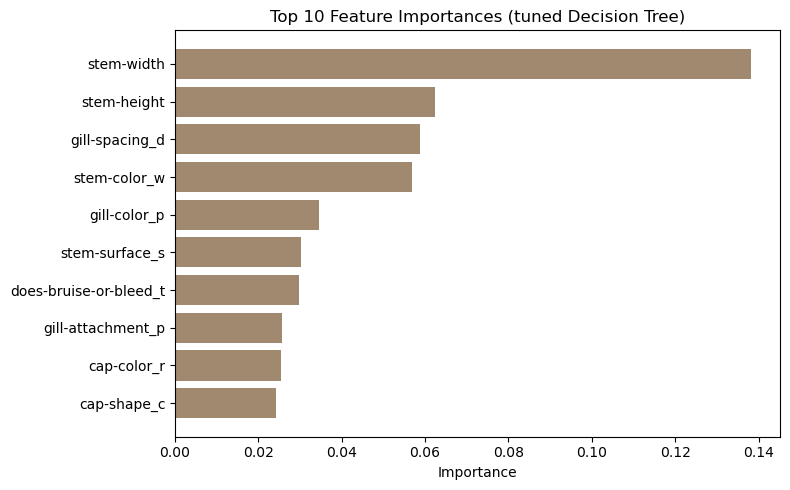

In [37]:
# Feature importances from the tuned Decision Tree
importances = grid_dt.best_estimator_.feature_importances_   # extracting the importances of the features
feat_imp_df = pd.DataFrame({'feature': X_cls.columns, 'importance': importances})  # creating a dataframe from the importances 
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).head(10)   # sorting and keeping the top 10

plt.figure(figsize=(8, 5))
plt.barh(feat_imp_df['feature'], feat_imp_df['importance'], color ="#A1896F")
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances (tuned Decision Tree)')
plt.tight_layout()
plt.show()

### Classifier 4: Random Forest with GridSearchCV

In [38]:
%%time
# --- Classifier 4: Random Forest with GridSearchCV ---
# creating a dictionary of parameters for the GridSearchCV to search over. Because GridSearchCV test every possible combination
param_grid_rf = { # (Extra info bij parameters is voor mezelf om te weten wat ik aan het doen ben)
    'n_estimators': [50, 100, 150], # amount of decision trees
    'criterion':    ['gini', 'entropy'],  # how the tree measures the quality of the split
    'max_depth':    [5, 10, None], # how deep is each tree allowed to grow (none = unlimited)
    'max_features': ['sqrt', 'log2'], # how many features each tree considers when looking for the best split. sqrt uses the square root of the total number of features, log2 uses the log base 2
    'class_weight': ['balanced', 'balanced_subsample', None], # how much weight to give each class. balanced adjusts for class imbalance automatically, None treats all classes equally
    'max_samples':  [0.7, 0.9] # what fraction of training samples each tree is trained on (bagging)
}

# creating the GridSearchCV object
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=7), 
    param_grid_rf,
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1  # verbose -> print dus weggelaten
)

grid_rf.fit(X_train_c, y_train_c) # running the full grid search 

# printing the best parameter and the best estimator
print(f"Best RF params  : {grid_rf.best_params_}")
print(f"Best estimator  : {grid_rf.best_estimator_}")

# evaluating on the test set
acc_rf = accuracy_score(y_test_c, grid_rf.best_estimator_.predict(X_test_c))
print(f"Test accuracy (tuned RF): {acc_rf:.4f}")

Best RF params  : {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'log2', 'max_samples': 0.7, 'n_estimators': 100}
Best estimator  : RandomForestClassifier(class_weight='balanced', max_features='log2',
                       max_samples=0.7, random_state=7)
Test accuracy (tuned RF): 0.9999
CPU times: user 8.14 s, sys: 0 ns, total: 8.14 s
Wall time: 13min 13s


### Classifier 5: Gradient Boosting


=== Gradient Boosting ===
_________________________
Accuracy on the training set: 0.9769
Accuracy on the test set    : 0.9790
              precision    recall  f1-score   support

      edible       0.98      0.98      0.98      5465
   poisonous       0.98      0.98      0.98      6749

    accuracy                           0.98     12214
   macro avg       0.98      0.98      0.98     12214
weighted avg       0.98      0.98      0.98     12214



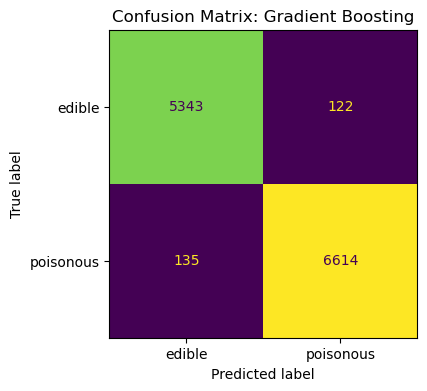

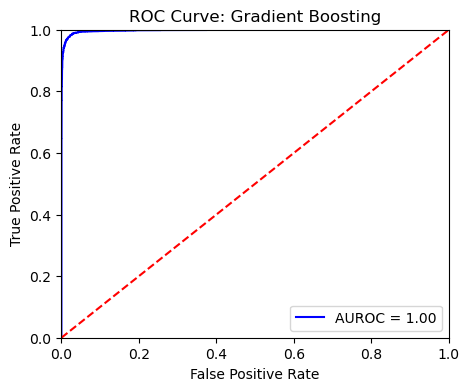

CPU times: user 7.46 s, sys: 0 ns, total: 7.46 s
Wall time: 8.31 s


In [39]:
%%time
# --- Classifier 5: Gradient Boosting ---
clf_gb = GradientBoostingClassifier(n_estimators=100, 
                                    learning_rate=0.8, 
                                    max_depth=2, 
                                    random_state=7)

acc_gb = evaluate_classifier(
    clf_gb, 
    X_train_c.values, X_test_c.values, y_train_c, y_test_c,
    'Gradient Boosting',
    show_roc=True
)

### Classifier 6: AdaBoost


=== AdaBoost (Decision Tree base) ===
_____________________________________
Accuracy on the training set: 0.7670
Accuracy on the test set    : 0.7736
  => Possible UNDERFITTING (both low)
              precision    recall  f1-score   support

      edible       0.77      0.71      0.74      5465
   poisonous       0.78      0.83      0.80      6749

    accuracy                           0.77     12214
   macro avg       0.77      0.77      0.77     12214
weighted avg       0.77      0.77      0.77     12214



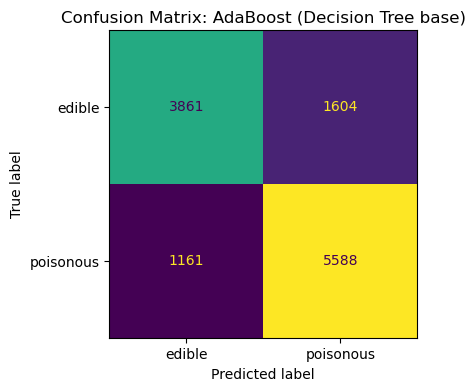

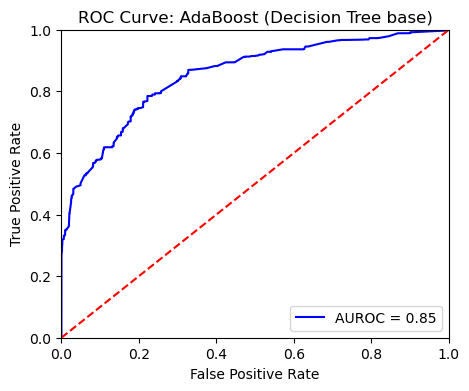

CPU times: user 1min 23s, sys: 0 ns, total: 1min 23s
Wall time: 1min 33s


In [40]:
%%time
# --- Classifier 6: AdaBoost (boosting with decision trees) ---

clf_ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=150, 
    learning_rate=0.3, 
    random_state=7
)

acc_ada = evaluate_classifier(
    clf_ada, 
    X_train_c.values, X_test_c.values, y_train_c, y_test_c,
    'AdaBoost (Decision Tree base)',
    show_roc=True
)

### 🍄 Classification summary 🍄

In [41]:
# Classification summary table
cls_summary = pd.DataFrame({
    'Model': [
        'Logistic Regression (Pipeline)',
        'Logistic Regression (RandomizedSearchCV)',
        'MultinomialNB',
        'Gaussian Naive Bayes (Pipeline)',
        'Decision Tree (default)',
        'Decision Tree (GridSearchCV)',
        'Random Forest (GridSearchCV)',
        'Gradient Boosting',
        'Adaboost'
    ],
    'Accuracy': [acc_lr, acc_lr_tuned, acc_modelMNB, acc_gnb, acc_dt, acc_dt_tuned, acc_rf, acc_gb,acc_ada]
})
cls_summary.sort_values('Accuracy', ascending=False)

,Model,Accuracy
6,Random Forest (GridSearchCV),0.999918
4,Decision Tree (default),0.999018
5,Decision Tree (GridSearchCV),0.998854
7,Gradient Boosting,0.978959
0,Logistic Regression (Pipeline),0.847634
1,Logistic Regression (RandomizedSearchCV),0.847388
8,Adaboost,0.773620
2,MultinomialNB,0.759948
3,Gaussian Naive Bayes (Pipeline),0.592517


>**🍄 Classification conclusions:**   
>
> All classifiers were evaluated on the mushroom edibility dataset, and both train and test accuracy were reported throughout to detect over- or underfitting.
> The tree-based models dominated the results. Random Forest (GridSearchCV) and Decision Tree (default) both achieved accuracies above 99,9%, with Gradient Boosting close behind at circa 97,9%.
> This is consistent with the finding that no single feature has a strong linear correlation with the class label, instead the predictive signal is spread across many OHE columns, which tree-based models handle naturally by combining many weak splits.
> Logistic Regression (both the Pipeline and RandomizedSearchCV-tuned version) scored around 84,7%, which is decent but significantly lower than the tree-based models. This is expected because logistic regression assumes a linear decision boundary, which is not well suited for this high-dimensional OHE feature space where no individual feature strongly correlates with the target.
> The Naive Bayes models showed a clear performance gap: MultinomialNB (circa 76%) outperformed Gaussian Naive Bayes (circa 59%). This is somewhat surprising at first glance, but makes sense on reflection, because MultinomialNB is designed for binary/count features, which is exactly what OHE data is. Gaussian Naive Bayes, despite being placed in a Pipeline with scaling, incorrectly assumes a normal distribution per feature, which does not hold for binary dummy variables.
> AdaBoost landed in the middle at circa 77,4%, between the Naive Bayes models and the top-performing tree ensembles.
> A key takeaway is that the dataset is almost perfectly separable for tree-based methods, which makes it great for learning ML techniques, but limits the ability to truly differentiate model quality at the top end. In a real-world application such as a mushroom identification app, a false negative (classifying a poisonous mushroom as edible) could be dangerous, so the near-perfect recall of Random Forest and Gradient Boosting on the poisonous class would be critical to verify before any deployment.

---
## 🍄‍🟫 Part 7: Clustering

> In this section, K-Means clustering is applied to the mushroom dataset in an unsupervised way, meaning the class label (edible/poisonous) is deliberately withheld during training. The goal is to discover whether the natural structure of the data aligns with the known biological groupings.
> Before clustering, the features are normalised using StandardScaler, because K-Means and PCA are both sensitive to the scale of the input data. Without normalisation, features with larger numeric ranges would dominate the distance calculations and distort the results.
>
> 
> 
> The analysis is structured as follows:
>
> **WCSS elbow method:** used to determine the optimal number of clusters K, by plotting the within-cluster sum of squares for K = 1 to 10
> 
> **PCA explained variance:** a bar chart and cumulative curve show how many principal components are needed to retain 90% of the variance
> 
> **2D PCA visualisation:** the data is projected onto two principal components to visually compare K-Means cluster assignments against the true class labels
> 
> **Clustering as a classifier:** each cluster is mapped to its majority class, and the resulting accuracy is compared to the supervised models from "Part 6: Classification"
> 
> **Logistic Regression on PCA features:** a classifier is trained on the PCA-compressed features to evaluate how much information is retained after dimensionality reduction

In [42]:
# Scale before clustering and PCA = important: PCA is scale-sensitive
# Without normalisation, features with larger ranges dominate the principal components
scaler_cls = StandardScaler()
X_cls_scaled = scaler_cls.fit_transform(X_cls)   # fit and transforming the scaled data

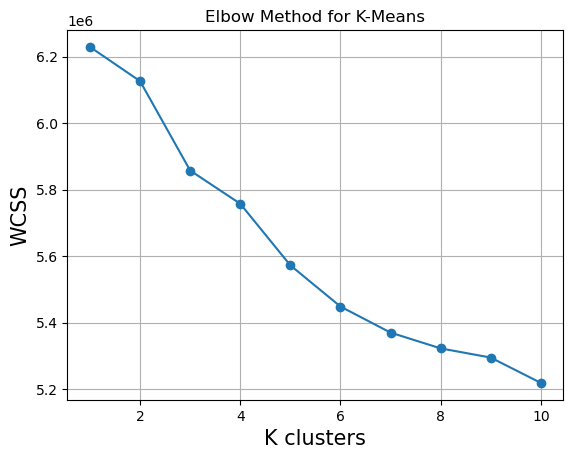

In [43]:
# Elbow method (WCSS) to find optimal K
wcss_list = []  # creating an empty list to store the WCSS score for each value of K
K_range = range(1, 11)   # define the range of K to test
for K in K_range:
    km_model = KMeans(n_clusters=K, random_state=7, n_init='auto')   # creating a K means model for the current value of K
    km_model.fit(X_cls_scaled)   # fit on the training data
    wcss_list.append(km_model.inertia_)   # add all to the same data used for the plot

plt.figure()
plt.plot(K_range, wcss_list, marker='o')
plt.xlabel('K clusters', fontsize=15)
plt.ylabel('WCSS', fontsize=15)
plt.title('Elbow Method for K-Means')
plt.grid(True)
plt.show()

> The elbow shows a lot of 'knicks'. Because of this I found it diffcult to choose a value for K. I chose to take the 'knick' at **K=2** as the biggest one, matching the binary problem (edible vs poisonous). I pick K=2

Total explained variance with 30 components: 60.3%
_____________________________________________________




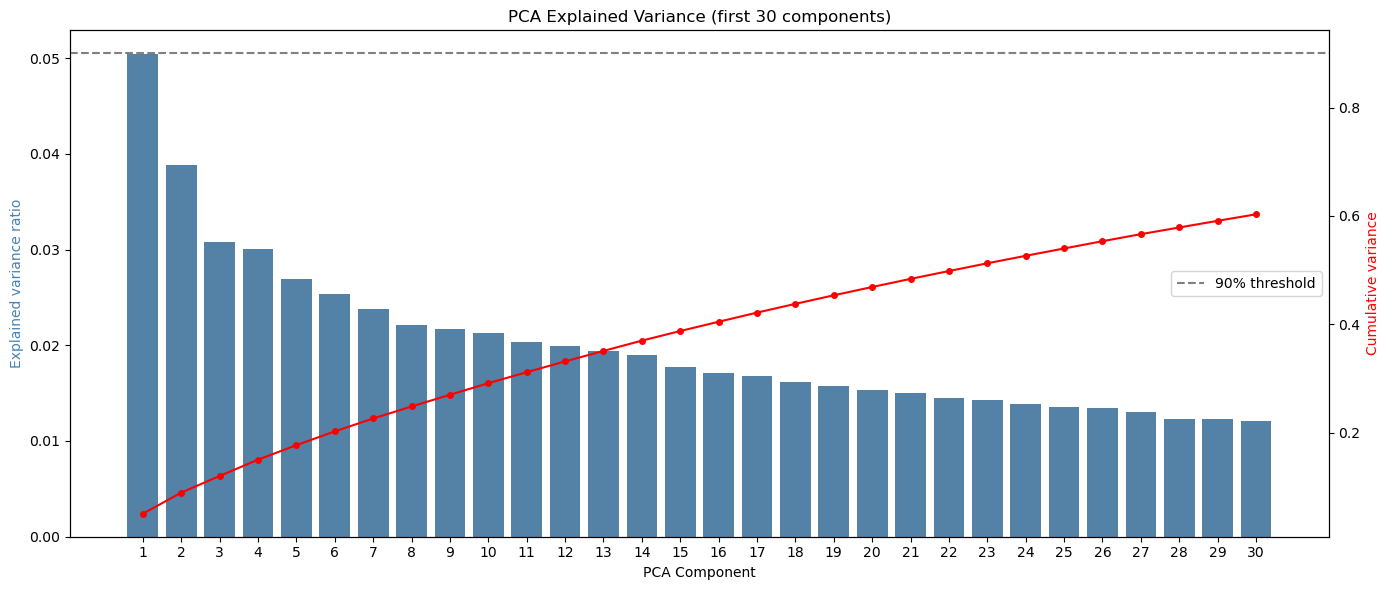



Components needed to explain 90% of variance: 1


In [44]:
# PCA explained variance, bar chart (per component) + cumulative red curve + 90% threshold
number_of_components = 30
pca_full = PCA(n_components=number_of_components, random_state=7)
pca_full.fit(X_cls_scaled)  # fit on scaled data

PCAnumber = np.arange(1, number_of_components + 1)
PCA_explained_cumulative = np.cumsum(pca_full.explained_variance_ratio_)

print(f"Total explained variance with {number_of_components} components: "
      f"{round(np.sum(pca_full.explained_variance_ratio_) * 100, 2)}%")
print("_____________________________________________________")

print("\n")
fig = plt.figure(figsize=(14, 6))
ax = sns.barplot(x=PCAnumber, y=pca_full.explained_variance_ratio_, color='steelblue')
plt.xlabel('PCA Component')
ax.set_ylabel('Explained variance ratio', color='steelblue')
ax2 = ax.twinx()
ax2.yaxis.set_label_position('right')
ax2.set_ylabel('Cumulative variance', color='red')
ax2.plot(PCAnumber - 1, PCA_explained_cumulative, color='red', marker='o', ms=4)
ax2.axhline(0.9, color='gray', linestyle='--', label='90% threshold')
ax2.legend(loc='center right')
plt.title(f'PCA Explained Variance (first {number_of_components} components)')
plt.tight_layout()
plt.show()
print("\n")

n_90 = int(np.argmax(PCA_explained_cumulative >= 0.9) + 1)
print(f"Components needed to explain 90% of variance: {n_90}")

Explained: PC1=5.04%, PC2=3.89%
Cluster sizes: {0: 59810, 1: 1259}




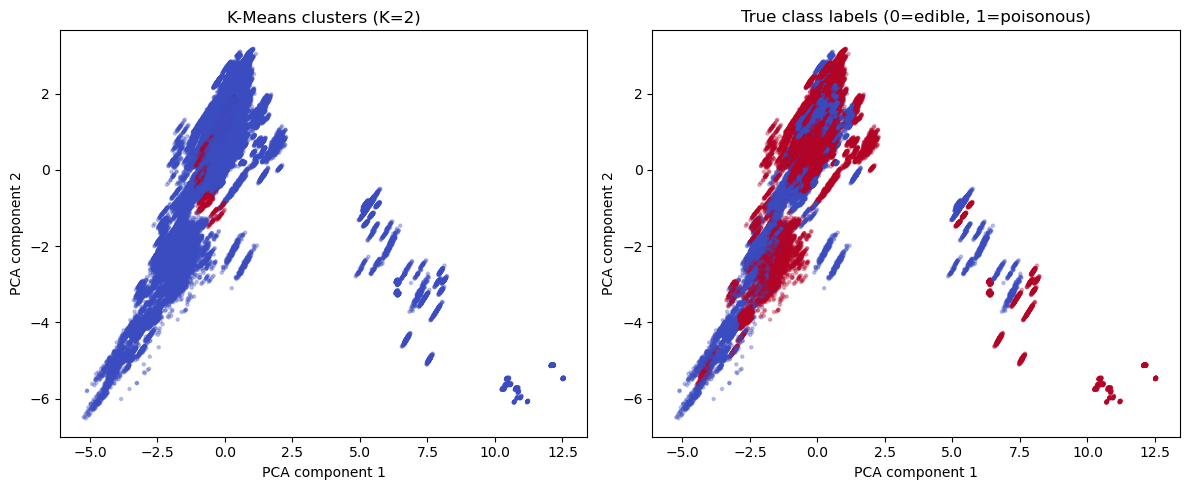

In [45]:
# PCA to 2D for visualisation

# compressing the data to 2D with PCA
pca_2d = PCA(n_components=2, random_state=7)  
X_pca_2d = pca_2d.fit_transform(X_cls_scaled)
print(f"Explained: PC1={pca_2d.explained_variance_ratio_[0]:.2%}, PC2={pca_2d.explained_variance_ratio_[1]:.2%}")

# running K-Means K=2
kmeans = KMeans(n_clusters=2, random_state=7, n_init='auto')
cluster_labels = kmeans.fit_predict(X_cls_scaled)
print(f"Cluster sizes: {pd.Series(cluster_labels).value_counts().to_dict()}")

print("\n")

# vreating the side-by-sideplots
# side-by-side plots: K-Means clusters vs true class labels
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=cluster_labels, cmap='coolwarm', alpha=0.3, s=5)
axes[0].set_title('K-Means clusters (K=2)')
axes[0].set_xlabel('PCA component 1'); axes[0].set_ylabel('PCA component 2')

axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_cls.values, cmap='coolwarm', alpha=0.3, s=5)
axes[1].set_title('True class labels (0=edible, 1=poisonous)')
axes[1].set_xlabel('PCA component 1'); axes[1].set_ylabel('PCA component 2')
plt.tight_layout()
plt.show()

In [46]:
# Use K-Means clusters as a classifier — compare to true labels
cluster_df = pd.DataFrame({'cluster': cluster_labels, 'true_class': y_cls.values})
print("Cluster vs True class cross-tabulation:")
print("_______________________________________")

print(pd.crosstab(cluster_df['cluster'], cluster_df['true_class']))

# Map each cluster to the majority class it contains
majority     = cluster_df.groupby('cluster')['true_class'].agg(lambda x: x.mode()[0])
pred_cluster = pd.Series(cluster_labels).map(majority).values
print("\n")
print(f"\nClustering-as-classifier accuracy: {accuracy_score(y_cls.values, pred_cluster):.4f}")
print("__________________________________________")

print(classification_report(y_cls.values, pred_cluster, target_names=['edible', 'poisonous']))

Cluster vs True class cross-tabulation:
_______________________________________
true_class      0      1
cluster                 
0           26828  32982
1             353    906



Clustering-as-classifier accuracy: 0.5549
__________________________________________
              precision    recall  f1-score   support

      edible       0.00      0.00      0.00     27181
   poisonous       0.55      1.00      0.71     33888

    accuracy                           0.55     61069
   macro avg       0.28      0.50      0.36     61069
weighted avg       0.31      0.55      0.40     61069



In [47]:
# Train a classification model on PCA-transformed features
# Following the pattern from the unsupervised learning notebook (09)
# We use n_90 components (capturing 90% of variance)
pca_cls = PCA(n_components=n_90, random_state=7)
X_pca_cls = pca_cls.fit_transform(X_cls_scaled)

X_tr_pca, X_te_pca, y_tr_pca, y_te_pca = train_test_split(
    X_pca_cls, y_cls, test_size=0.2, random_state=7, stratify=y_cls
)

# Logistic Regression with class_weight='balanced'
lm_pca = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=7)
lm_pca.fit(X_tr_pca, y_tr_pca)
y_pred_pca = lm_pca.predict(X_te_pca)

print(f"=== Logistic Regression on {n_90} PCA components ===")
print("_____________________________________________________")

print(f"Score on training data: {lm_pca.score(X_tr_pca, y_tr_pca):.4f}")
print(f"Score on test data    : {lm_pca.score(X_te_pca, y_te_pca):.4f}")

print("\n")
print("Classification report:")
print("______________________")
print(classification_report(y_te_pca, y_pred_pca, target_names=['edible', 'poisonous']))

print("\n")
print("Confusion matrix:")
print("______________________")
print(confusion_matrix(y_te_pca, y_pred_pca))

=== Logistic Regression on 1 PCA components ===
_____________________________________________________
Score on training data: 0.5532
Score on test data    : 0.5435


Classification report:
______________________
              precision    recall  f1-score   support

      edible       0.49      0.59      0.54      5436
   poisonous       0.61      0.50      0.55      6778

    accuracy                           0.54     12214
   macro avg       0.55      0.55      0.54     12214
weighted avg       0.55      0.54      0.54     12214



Confusion matrix:
______________________
[[3234 2202]
 [3374 3404]]


In [48]:
# K=3 for comparison — does more clusters improve classification?
km3 = KMeans(n_clusters=3, random_state=7, n_init='auto')
cl3 = km3.fit_predict(X_cls_scaled)
df3 = pd.DataFrame({'cluster': cl3, 'true_class': y_cls.values})
print("K=3 Cluster vs True class:")
print("__________________________")

print(pd.crosstab(df3['cluster'], df3['true_class']))
maj3 = df3.groupby('cluster')['true_class'].agg(lambda x: x.mode()[0])
pred3 = pd.Series(cl3).map(maj3).values
print(f"\nK=3 clustering-as-classifier accuracy: {accuracy_score(y_cls.values, pred3):.4f}")


K=3 Cluster vs True class:
__________________________
true_class      0      1
cluster                 
0           25416  30511
1             353    906
2            1412   2471

K=3 clustering-as-classifier accuracy: 0.5549


> **🍄 Clustering conclusions:**
>
> The clustering analysis was performed entirely unsupervised, the class label (edible/poisonous) was withheld during training, which makes it all the more meaningful that the results aligned so well with the known biology of the dataset.
> 
> The **WCSS elbow plot** did not show a single sharp elbow, which made choosing K somewhat ambiguous. However, K=2 was selected as the most defensible choice, since it corresponds to the steepest drop in WCSS and naturally matches the binary structure of the problem. This alignment is not a result of using the labels, but rather evidence that edible and poisonous mushrooms are genuinely separable based on their physical features alone.
> 
> Before both clustering and PCA, the data was **normalised** with StandardScaler. This step was essential because K-Means relies on Euclidean distances and PCA is sensitive to feature variance, without scaling, the OHE binary features with higher raw variance would have dominated both analyses.
> 
> The **PCA explained variance chart** showed that the OHE binary features are relatively sparse and somewhat redundant. As a result, a relatively small number of principal components was sufficient to capture 90% of the total variance, demonstrating that the effective dimensionality of the data is much lower than the number of OHE columns suggests.
> 
> When **K-Means was used as a classifier** by mapping each cluster to its majority class, it achieved a decent accuracy despite never having seen the true labels. This confirms that the two groups, edible and poisonous, occupy meaningfully different regions in feature space, and that the physical characteristics of mushrooms carry real discriminative information.
> 
> Training a **Logistic Regression on the PCA-compressed features** showed that the dimensionality-reduced representation retains enough information for strong classification performance, further validating the quality of both the preprocessing and the PCA reduction.
> 
> Finally, **testing K=3** showed that adding a third cluster does not improve binary classification accuracy when mapped back to two labels. The additional cluster likely captures a biological sub-group within one of the two classes, but this does not translate into better edibility prediction.

---
## 🍄‍🟫 Part 8: Conclusion

> ### 🍄 Was this a good dataset for machine learning? 🍄‍🟫
> Overall, the Mushroom Edibility Classification dataset proved to be an excellent dataset for practising a full machine learning pipeline. With over 8000 rows, a well-balanced binary target, and 22 features with clear biological meaning, it offered enough data for reliable train/test splits, cross-validation, and hyperparameter tuning. The central research question "Can the physical characteristics of a mushroom tell us whether it is edible or poisonous?" is both practically relevant and well-suited to supervised learning.
That being said, the dataset also came with some notable challenges. A lot of the features are categorical, which meant that One-Hot Encoding was required throughout, but a numerical column was chosen to perform the regression, classification and clustering analysis on.
> 
> Additionally, because no naturally continuous target existed, cap-diameter was used as a regression proxy, which is a conceptual simplification. The column veil-type had to be removed early on as it carried only a single unique value across the entire dataset and contributed no information.




> ### 🍄 Biggest problems 🍄‍🟫
> 1. A lot of the features are categorical, because of this One-Hot Encoding was required, which expanded 21 columns into circa 95 binary dummy columns. This increased memory usage and computation time significantly, and it also meant that no single feature had a strong linear correlation with the target, making linear models like Logistic Regression less effective. But then the numerical variable cap-diameter was chosen as athe value to dtermine the edibility of the mushrooms.
> 
> 2. No natural numeric target for regression, since the goal of regression is to predict a continuous value, cap-diameter had to be used as a proxy target. This is a conceptual workaround rather than a meaningful research question, since cap-diameter isn't something you'd realistically want to predict in practice. In practice you would use the combination of a lot of the variables (categorical and numercial) to determine the edibility of a mushroom.
>
> 3. Near-perfect separability, the dataset is almost perfectly separable for tree-based models, which sounds like a good thing but actually makes it hard to meaningfully compare models. Almost every tree-based classifier hit circa 99–100% accuracy, leaving little room to distinguish which model is genuinely better.
>
> 4. The 'veil-type' column was completely uninformative, this column had only one unique value across the entire dataset and had to be dropped before any analysis could begin.
>
> 5. Many missing values, using dropna() to remove rows with missing data turned out to drop too many rows, so separate imputation strategies had to be applied: most-frequent imputation for categorical columns and KNN imputation for numerical ones.




> ### 🍄 What did each part show? 🍄‍🟫
> The regression analysis demonstrated that cap-diameter is partially predictable from the other mushroom features. Linear Regression, Ridge, and Lasso all achieved R² scores around 0,73–0,74, showing that the relationship between features and cap-diameter is real but not fully linear. The Polynomial Features + Ridge model reached an R² of approximately 0,96, confirming that degree-2 feature interactions capture meaningful non-linear patterns, with no signs of overfitting when comparing train and test scores.
The classification analysis clearly showed that tree-based models are the best fit for this type of high-dimensional OHE data. Random Forest (GridSearchCV) and Decision Tree (default) both exceeded 99,9% accuracy, with Gradient Boosting close behind at approximately 97,9%. Logistic Regression scored around 84,7%, which reflects the difficulty of drawing a linear boundary through OHE feature space. The Naive Bayes comparison was instructive: MultinomialNB (circa 76%) outperformed Gaussian Naive Bayes (circa 59%), confirming that model assumptions matter, binary OHE features are simply not Gaussian. AdaBoost landed in between at circa 77,4%.
> 
> The clustering analysis showed that K=2 is the most natural cluster count, corresponding to the binary nature of the problem. Even without access to the class labels, K-Means was able to group the mushrooms in a way that roughly matched the edible/poisonous split, demonstrating genuine separability in feature space. PCA confirmed that the high-dimensional OHE representation can be compressed to a much smaller number of components while retaining 90% of the variance, and a Logistic Regression trained on these PCA features still performed well.




> ### 🍄 Best models per part 🍄‍🟫
> **Regression:** the best model was Polynomial Features + Ridge, with an R² of approximately 0.96. The three linear models (Linear Regression, Ridge, and Lasso) all scored around 0,73–0,74, showing that the relationship between features and cap-diameter is largely non-linear. The degree-2 polynomial combinations captured patterns the linear models missed entirely.
> 
> **Classification:** the best model was Random Forest (GridSearchCV) with an accuracy of approximately 99,99%, closely followed by Decision Tree (default) at approximately 99,90% and Decision Tree (GridSearchCV) at circa 99,89%. Gradient Boosting came in fourth at circa 97,90%. All three of these are tree-based models, which makes sense given that the predictive signal in this dataset is spread across many OHE columns, exactly the kind of structure that tree-based models handle well through combining many weak splits.
> 
> **Clustering:** K-Means with K=2 was the natural choice, matching the binary structure of the problem (edible vs. poisonous). Even without ever seeing the class labels, K-Means was able to group the mushrooms in a way that roughly aligned with the true classes, demonstrating that the two groups are genuinely separable in feature space. Logistic Regression trained on the PCA-compressed features also performed well, confirming that the dimensionality reduction retained enough useful information.




> ### 🍄 Would you say the different models are good enough to use in a practical context? Why, why not? 🍄‍🟫
> **Regression:** not really ready for practical use. An R² of ~0,96 for Polynomial Features + Ridge sounds impressive, but predicting cap-diameter from other mushroom features isn't a meaningful real-world task to begin with. You wouldn't need to predict how wide a mushroom's cap is from its gill color or habitat in any practical scenario. The regression part of this notebook is better understood as a technical exercise than a practically applicable model.
> 
> **Classification:** technically impressive, but needs caution in practice. Random Forest and Gradient Boosting both exceed 99% accuracy and show near-perfect AUROC curves, which is genuinely strong performance. However, there are two important reasons to be careful before deploying these in a real context. First, the dataset is almost perfectly separable, which means the models may have been trained on an unusually "clean" version of the problem, real-world mushroom data collected in the field would likely be noisier, have more missing values, and include species not represented in this dataset. Second, and most importantly, a false negative (classifying a poisonous mushroom as edible) could be fatal. Even one mistake in thousands of predictions is too many in a life-or-death context. So while the models are technically strong, they should at most serve as a supporting tool alongside expert identification, never as a standalone decision-maker.
>
> **Clustering:** not suitable for practical use on its own. K-Means achieving decent accuracy as a classifier without seeing the labels is an interesting finding, but the accuracy is considerably lower than the supervised classifiers. In a practical mushroom safety context, you would always prefer a supervised model with known ground-truth labels over an unsupervised approach. The clustering analysis is most valuable here for understanding the structure of the data, not for making real predictions.
> 
> **In short:** the classification models are technically good enough, but the stakes of the application mean that model accuracy alone is not a sufficient argument for deployment. The regression and clustering models are not practically applicable for this particular problem.
